# Notebook 1: Data Exploration

**NYU Deep Learning Spring 2026 — Text-to-SVG Kaggle Competition**

### Purpose
Before training any model, we need to understand the data we are working with.
This notebook answers the following questions:

1. What do the prompts look like? How long are they?
2. What do the SVGs look like? How complex are they?
3. How long are the SVGs in characters + what does that mean for token budget?
4. Which training examples should we keep vs. filter out?
5. Are there any invalid or malformed SVGs in the training set?

The answers to these questions will directly determine our `max_seq_length`,
our dataset size, and our training strategy in Notebook 2.

### Competition constraint reminders
- Output SVGs must be **≤ 8,000 characters**
- Canvas must be **256×256 pixels**
- Max **256 path elements**
- Only specific tags allowed (svg, g, path, rect, circle, ellipse, line, polyline, polygon). No scripts, no animations.
- Any invalid SVG scores **zero** -> we need to hard gate this so they don't drag our score down

## 0 Install dependencies

In [ ]:
# Install required packages.
# cairosvg: SVG renderer, rasterize SVG to PNG (same one used by the competition scorer + tutorial)
# datasets: HuggingFace library for loading the uploaded train/test data
%pip install -q cairosvg datasets pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 3.7 MB/s eta 0:00:00


## 1 Load the data

We uploaded `train.csv` and `test.csv` to a public HuggingFace dataset repo.
Loading from HuggingFace means we don't need to manually upload files to Colab
every session and can just directly stream the data.

Since the dataset is public, no token is needed to load it.
If you want to use your own copy, change `HF_DATASET_REPO` to your repo path,
or set `USE_HUGGINGFACE = False` and point the local paths at your downloaded CSVs.

In [ ]:
import os
import pandas as pd
import numpy as np
from collections import Counter
from datasets import load_dataset
import matplotlib.pyplot as plt

# DATA SOURCE
# Option A: load from HuggingFace (default, no token needed for public repos)
USE_HUGGINGFACE  = True
HF_DATASET_REPO  = "aagoluoglu/text-to-svg"

# Option B: load from local files
# Download train.csv and test.csv from the Kaggle competition page,
# place them in a data/ folder next to this notebook, then set USE_HUGGINGFACE = False
LOCAL_TRAIN_PATH = "data/train.csv"
LOCAL_TEST_PATH  = "data/test.csv"


if USE_HUGGINGFACE:
    dataset  = load_dataset(
        HF_DATASET_REPO,
        data_files={"train": "train.csv", "test": "test.csv"},
    )
    train_df = dataset["train"].to_pandas()
    test_df  = dataset["test"].to_pandas()
else:
    train_df = pd.read_csv(LOCAL_TRAIN_PATH)
    test_df  = pd.read_csv(LOCAL_TEST_PATH)

print(f"Train rows : {len(train_df):,}")
print(f"Test rows  : {len(test_df):,}")
print(f"\nTrain columns: {list(train_df.columns)}")
print(f"Test columns : {list(test_df.columns)}")

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/135M [00:00<?, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Train rows : 50,000
Test rows  : 1,000

Train columns: ['id', 'prompt', 'svg']
Test columns : ['id', 'prompt', 'svg']


## 2 Preview a few rows

It's best to look at raw data before doing anything else.
This catches encoding issues, unexpected columns, or obvious anomalies early. Learned this the hard way rip.

In [ ]:
# Display the first few rows, truncate svg so it doesn't flood the output
display_df = train_df.copy()
display_df["svg"] = display_df["svg"].str[:80] + "..."
display(display_df.head(5))

,id,prompt,svg
0,fd61e324e0cec5c11f337d0bfe2858c8,The image features two orange squares with a m...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
1,999b3d4d5a860725bf9528910b5612f3,A simple smiley face with a wide open mouth an...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
2,1aaa84517819c25f783ae1c0cb337fc5,The image features a black-outlined icon of a ...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
3,919a7da8bd44dc7781dbe87383a268cc,The image displays a black icon with a photo-l...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
4,thesantatitan_deepseek-svg-dataset_0000581,Generate svg code for an image that looks like...,"<svg width=""24"" height=""24"" viewBox=""0 0 24 24..."


In [ ]:
# Print one full example to see the actual SVG structure
# Pick a diff index to choose diff examples
EXAMPLE_IDX = 1

print("=" * 60)
print("PROMPT:")
print(train_df.loc[EXAMPLE_IDX, "prompt"])
print("\nSVG (first 500 chars):")
print(train_df.loc[EXAMPLE_IDX, "svg"][:500])
print("\nFull SVG length:", len(train_df.loc[EXAMPLE_IDX, "svg"]), "characters")

PROMPT:
A simple smiley face with a wide open mouth and straight eyes.

SVG (first 500 chars):
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#040000" fill-opacity="1.0"  filling="0" d="M100.3030014038086 11.76300048828125 C51.808998107910156 11.76300048828125 12.494003295898438 51.07899856567383 12.494003295898438 99.58000183105469 C12.494003295898438 148.0760040283203 51.808998107910156 187.39199829101562 100.3030014038086 187.39199829101562 C148.79600524902344 187.39199829101562 188.1230010986328 148.0749969482422 188.

Full SVG length: 3166 characters


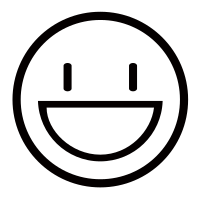

In [ ]:
# Render the example SVG inline to visually confirm it looks right
# Use IPython's SVG display like tutorial notebook
from IPython.display import SVG, display
display(SVG(data=train_df.loc[EXAMPLE_IDX, "svg"]))

## 3 Check for missing or invalid data

Before computing any statistics, we need to know if the dataset has
nulls or empty strings that would corrupt our analysis.

Null values:

In [ ]:
print("Null values in train:")
print(train_df.isnull().sum())
print("\nNull values in test:")
print(test_df.isnull().sum())

Null values in train:
id        0
prompt    0
svg       0
dtype: int64

Null values in test:
id           0
prompt       0
svg       1000
dtype: int64


Empty strings:

In [ ]:
# Empty strings are different from null
empty_prompts = (train_df["prompt"].str.strip() == "").sum()
empty_svgs    = (train_df["svg"].str.strip() == "").sum()
print(f"Empty prompts : {empty_prompts}")
print(f"Empty SVGs    : {empty_svgs}")

Empty prompts : 0
Empty SVGs    : 0


## 4 Prompt analysis

Understanding the prompts tells shows what kinds of descriptions the model needs to handle. Ex: short icon descriptions or longer scene descriptions?

Prompt length statistics:

In [ ]:
# Basic prompt length statistics
train_df["prompt_len"]   = train_df["prompt"].str.len()
train_df["prompt_words"] = train_df["prompt"].str.split().str.len()

print("Prompt character length:")
print(train_df["prompt_len"].describe().round(1))
print("\nPrompt word count:")
print(train_df["prompt_words"].describe().round(1))

# Percentiles
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    chars = np.percentile(train_df["prompt_len"], p)
    words = np.percentile(train_df["prompt_words"], p)
    print(f"  P{p:02d}:  {chars:.0f} chars  |  {words:.0f} words")

Prompt character length:
count    50000.0
mean       116.6
std         64.2
min          5.0
25%         72.0
50%        103.0
75%        137.0
max        860.0
Name: prompt_len, dtype: float64

Prompt word count:
count    50000.0
mean        19.7
std         10.3
min          1.0
25%         12.0
50%         17.0
75%         24.0
max        127.0
Name: prompt_words, dtype: float64
  P01:  37 chars  |  7 words
  P05:  49 chars  |  9 words
  P10:  55 chars  |  10 words
  P25:  72 chars  |  12 words
  P50:  103 chars  |  17 words
  P75:  137 chars  |  24 words
  P90:  191 chars  |  32 words
  P95:  252 chars  |  41 words
  P99:  353 chars  |  57 words


In [ ]:
# Test prompt length and word count statistics
# Compare directly to training stats above — if distributions are similar,
# the model's learned prompt understanding should transfer well to test set

test_df["prompt_len"]   = test_df["prompt"].str.len()
test_df["prompt_words"] = test_df["prompt"].str.split().str.len()

print("Test prompt character length:")
print(test_df["prompt_len"].describe().round(1))
print("\nTest prompt word count:")
print(test_df["prompt_words"].describe().round(1))

for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    chars = np.percentile(test_df["prompt_len"], p)
    words = np.percentile(test_df["prompt_words"], p)
    print(f"  P{p:02d}:  {chars:.0f} chars  |  {words:.0f} words")

Test prompt character length:
count    1000.0
mean      119.3
std        67.5
min        12.0
25%        73.0
50%       104.5
75%       139.0
max       488.0
Name: prompt_len, dtype: float64

Test prompt word count:
count    1000.0
mean       20.1
std        10.8
min         2.0
25%        13.0
50%        17.0
75%        24.2
max        85.0
Name: prompt_words, dtype: float64
  P01:  37 chars  |  7 words
  P05:  49 chars  |  9 words
  P10:  56 chars  |  10 words
  P25:  73 chars  |  13 words
  P50:  104 chars  |  17 words
  P75:  139 chars  |  24 words
  P90:  210 chars  |  34 words
  P95:  263 chars  |  43 words
  P99:  362 chars  |  60 words


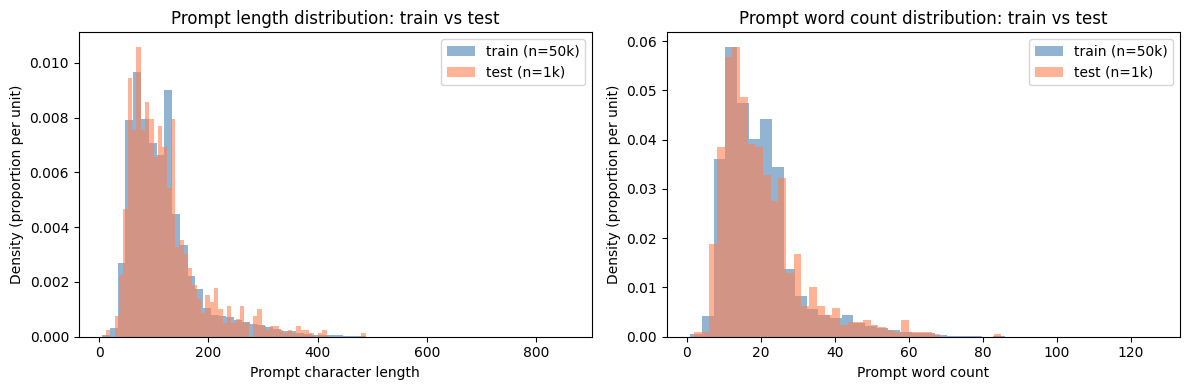

In [ ]:
# Side-by-side comparison of train vs test prompt length distributions
# Using percentages on y-axis since datasets are different sizes (50k vs 1k)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df["prompt_len"], bins=60, alpha=0.6, color="steelblue",
             label="train (n=50k)", edgecolor="none", density=True)
axes[0].hist(test_df["prompt_len"],  bins=60, alpha=0.6, color="coral",
             label="test (n=1k)",   edgecolor="none", density=True)
axes[0].set_xlabel("Prompt character length")
axes[0].set_ylabel("Density (proportion per unit)")
axes[0].set_title("Prompt length distribution: train vs test")
axes[0].legend()

axes[1].hist(train_df["prompt_words"], bins=40, alpha=0.6, color="steelblue",
             label="train (n=50k)", edgecolor="none", density=True)
axes[1].hist(test_df["prompt_words"],  bins=40, alpha=0.6, color="coral",
             label="test (n=1k)",   edgecolor="none", density=True)
axes[1].set_xlabel("Prompt word count")
axes[1].set_ylabel("Density (proportion per unit)")
axes[1].set_title("Prompt word count distribution: train vs test")
axes[1].legend()

plt.tight_layout()
plt.show()

### Observation: Complexity Distributions look similar on Training and Test sets

### Decision: no need for complexity balancing in dataset

We were originally going to stratify the sampling by trying to match the complexity of the test set with some heuristic scores based on words like "simple" or "several" (short vs more complex prompt requests), but decided it is not needed, as the train and test prompts seem to match fairly closely.

10 random training prompts:

In [ ]:
# Print 10 random prompts to see general writing style and content
print("10 random training prompts:\n")
for i, prompt in enumerate(train_df["prompt"].sample(10, random_state=42).values):
    print(f"{i+1:2d}. {prompt}")

10 random training prompts:

 1. A black icon featuring a vertical rectangle with horizontal lines at the top and a teardrop shape centered in the lower half against a white background.
 2. A single black outline of a heart shape against a white background.
 3. The image features a black-and-white geometric design consisting of a square frame with three vertical lines inside it, positioned centrally within the frame. Additional small black lines are located at the top and bottom centers of the square frame.
 4. A simple line graph with a rising trend depicted by connected points.
 5. The image features a simple, monochromatic drawing of a planet or celestial body with three circular rings in brown against a white background.
 6. The image shows a red cylindrical shape with horizontal lines, resembling a database icon or a stack of disks.
 7. The image shows a black-and-white icon of a computer monitor with coding symbols displayed on the screen against a white background.
 8. A silhoue

10 random test prompts:

In [ ]:
# Check the test prompts too, how similar in style to training?
# If very different, could need to be careful about prompt formatting during inference
print("10 random test prompts:\n")
for i, prompt in enumerate(test_df["prompt"].sample(10, random_state=42).values):
    print(f"{i+1:2d}. {prompt}")

10 random test prompts:

 1. The image shows a black icon of a stylized pencil with a pointed tip inside a black square border on a white background.
 2. An image features a black rectangular frame surrounding a white square, which contains two black circular shapes resembling eyes, each with a smaller white circle inside representing pupils. The right eye has a partial white triangle extending from its pupil, giving it an asymmetrical appearance.
 3. A speaker icon with concentric circles and corners marked by black dots, representing stereo audio equipment.
 4. A black arrow icon with a bold downward pointing arrow and two curved lines on either side, set against a white background.
 5. The image features a blue icon with a square outline containing a black box with a wave-like bottom edge, two horizontal blue lines inside the box, and a darker blue curved line at the top.
 6. A black shopping cart icon is centrally positioned against a white background. The cart features a horizonta

Check for duplicates:

In [ ]:
# Duplicate Analysis
dup_prompt = train_df["prompt"].duplicated().sum()
dup_svg = train_df["svg"].duplicated().sum()
dup_both = train_df.duplicated(subset=["prompt", "svg"]).sum()
print(f"\nDuplicate prompts:       {dup_prompt}")
print(f"Duplicate SVGs:          {dup_svg}")
print(f"Duplicate (prompt+svg):  {dup_both}")


Duplicate prompts:       4069
Duplicate SVGs:          7
Duplicate (prompt+svg):  0


Examine extremes (very long/very short) and common prompts & words:

In [ ]:
# Very short prompts (potential junk)
short_threshold = 5
short_prompts = train_df[train_df["prompt_len"] < short_threshold]
print(f"\nPrompts shorter than {short_threshold} chars: {len(short_prompts)}")
if len(short_prompts) > 0:
    print("  Examples:", short_prompts["prompt"].head(10).tolist())

# Very long prompts
long_threshold = 500
long_prompts = train_df[train_df["prompt_len"] > long_threshold]
print(f"\nPrompts longer than {long_threshold} chars: {len(long_prompts)}")
if len(long_prompts) > 0:
    print("  Examples (truncated):")
    for p in long_prompts["prompt"].head(5):
        print(f"    {p[:150]}...")

# Most common prompts
print("\n--- Most Common Prompts ---")
top_prompts = train_df["prompt"].value_counts().head(15)
for prompt, count in top_prompts.items():
    print(f"  [{count:4d}x] {prompt[:100]}")

# Common words
all_words = " ".join(train_df["prompt"].fillna("").str.lower()).split()
word_counts = Counter(all_words)
print("\n--- Top 30 Words in Prompts ---")
for word, count in word_counts.most_common(30):
    print(f"  {word:20s} {count:>7,}")


Prompts shorter than 5 chars: 0

Prompts longer than 500 chars: 18
  Examples (truncated):
    The image features a stylized, abstract design with bold, vibrant colors. At the center, there is a large, curved purple shape that resembles an eye, ...
    The image shows a black rectangular frame containing a stylized musical note symbol. Inside the frame, there is a vertical black line extending from t...
    The image features a stylized logo composed of bold, contrasting blue and white colors. The design includes a prominent chef's hat in white at the top...
    The image consists of a white background with four distinct black line-drawn icons arranged symmetrically. On the left side, there is a black antenna-...
    The image features a black circular arrow enclosing a central icon of a lightning bolt, all set against a white background. The circular arrow consist...

--- Most Common Prompts ---
  [1788x] Generate svg code for an image that looks like: a black background with a white

### Observation: There are many duplicate prompts, a handful of duplicate SVGs, no duplicate pairs

### Decision: Remove Duplicates (see later section)
For each duplicate prompt, find the simplest (shortest) SVG, and keep only that sample. Remove other samples.

## 5 SVG structure analysis

What SVG elements are most common in the training data.
This helps understand the complexity and style of SVGs to generate.

Also check path count. The competition enforces ≤ 256 paths.

### 5.1 Allowed / Required Elements

In [ ]:
import xml.etree.ElementTree as ET
import re

def count_paths(svg_str: str) -> int:
    """Count the number of <path> elements in an SVG string."""
    return len(re.findall(r"<path", svg_str, flags=re.IGNORECASE))


def count_element(svg_str: str, tag: str) -> int:
    """Count occurrences of a specific SVG tag."""
    return len(re.findall(f"<{tag}[\\s/>]", svg_str, flags=re.IGNORECASE))


# Compute path count on the FULL dataset
path_counts = train_df["svg"].apply(count_paths)

print(f"Total SVGs analyzed: {len(path_counts)}")
print("\nPath element count per SVG:")
print(path_counts.describe().round(1))
print(f"\nExamples with > 256 paths: {(path_counts > 256).sum()}")
print(f"Examples with > 128 paths: {(path_counts > 128).sum()}")
print(f"Examples with > 64 paths:  {(path_counts > 64).sum()}")

# Distribution buckets
bins = [0, 1, 5, 10, 20, 50, 100, 200, 500, float('inf')]
labels = ['0-1', '2-5', '6-10', '11-20', '21-50', '51-100', '101-200', '201-500', '500+']
print("\nPath count distribution:")
print(path_counts.groupby(pd.cut(path_counts, bins=bins, labels=labels)).count())

Total SVGs analyzed: 50000

Path element count per SVG:
count    50000.0
mean         2.4
std          3.4
min          0.0
25%          1.0
50%          1.0
75%          3.0
max        303.0
Name: svg, dtype: float64

Examples with > 256 paths: 1
Examples with > 128 paths: 2
Examples with > 64 paths:  5

Path count distribution:
svg
0-1        25097
2-5        19270
6-10        3146
11-20        847
21-50        181
51-100        16
101-200        2
201-500        1
500+           0
Name: svg, dtype: int64


/tmp/ipykernel_2646/2154746505.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(path_counts.groupby(pd.cut(path_counts, bins=bins, labels=labels)).count())


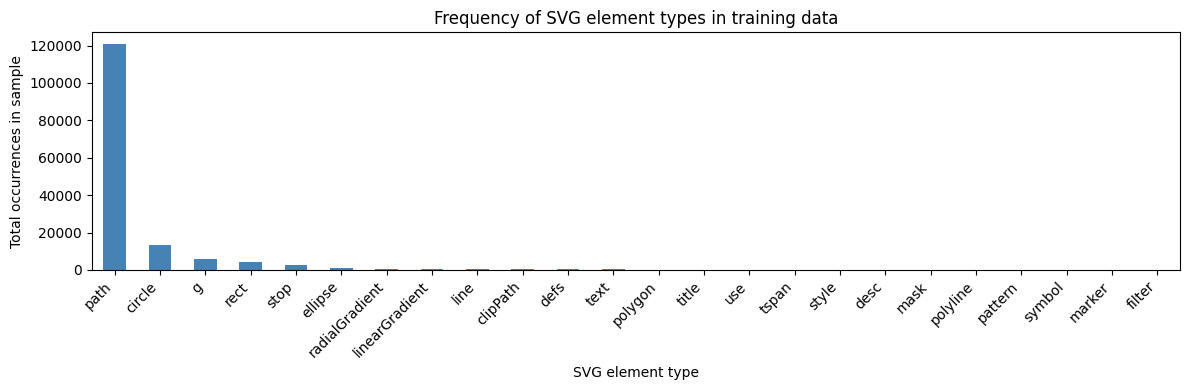

In [ ]:
# Count how often each SVG element type appears across the sample
# svg, g, path, rect, circle, ellipse,
# line, polyline, polygon, defs, use,
# symbol, clipPath, mask, linearGradient,
# radialGradient, stop, text, tspan, title,
# desc, style, pattern, marker, filter
ALLOWED_TAGS = [
    "g", "path", "rect", "circle", "ellipse",
    "line", "polyline", "polygon", "defs", "use",
    "symbol", "clipPath", "linearGradient", "mask",
    "radialGradient", "stop", "text", "tspan", "title",
    "desc", "style", "pattern", "marker", "filter"
]


tag_counts = {}
for tag in ALLOWED_TAGS:
    total = train_df["svg"].apply(
        lambda s: count_element(s, tag)
    ).sum()
    tag_counts[tag] = total

# Sort by frequency and display
tag_series = pd.Series(tag_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
tag_series.plot(kind="bar", ax=ax, color="steelblue", edgecolor="none")
ax.set_xlabel("SVG element type")
ax.set_ylabel("Total occurrences in sample")
ax.set_title("Frequency of SVG element types in training data")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5.2. Check for disallowed elements

The competition disallows some tags and any external references (href/src
pointing outside the SVG).

If the training data contains these, the model may learn to generate them
and score zero on those outputs, so they should be filtered out.

In [ ]:
# scripts, event handlers, animation, foreignObject, external references
DISALLOWED_TAGS = [
    "script",
    "animate",
    "animateTransform",
    "animateMotion",
    "foreignObject",
    "set",
]

print("Training examples containing disallowed elements:\n")
for tag in DISALLOWED_TAGS:
    has_tag = train_df["svg"].str.contains(f"<{tag}", case=False, regex=False)
    n = has_tag.sum()
    print(f"  <{tag}>: {n:,} examples ({100*n/len(train_df):.2f}%)")

Training examples containing disallowed elements:

  <script>: 0 examples (0.00%)
  <animate>: 0 examples (0.00%)
  <animateTransform>: 0 examples (0.00%)
  <animateMotion>: 0 examples (0.00%)
  <foreignObject>: 0 examples (0.00%)
  <set>: 0 examples (0.00%)


In [ ]:
# Also check for external references
# External references look like href="http..." or src="http..."
has_external = train_df["svg"].str.contains(r'href=["\']http', case=False, regex=True)
n_external = has_external.sum()
print(f"Examples with external href references: {n_external:,}")

Examples with external href references: 0


### 5.3 Path Complexity Analysis

In [ ]:
# Analyze path 'd' attribute lengths (usually the bulk of SVG size)
# Parse a sample (parsing all can be slow for very large datasets)
PARSE_SAMPLE_SIZE = min(5000, len(train_df))
sample_idx = np.random.RandomState(42).choice(len(train_df), PARSE_SAMPLE_SIZE, replace=False)
sample = train_df.iloc[sample_idx].copy()

path_d_lengths = []
path_command_counts = []

for i, (idx, row) in enumerate(sample.iterrows()):
    svg_text = str(row["svg"]).strip()
    try:
        root = ET.fromstring(svg_text)
        for elem in root.iter():
            tag = elem.tag.split("}")[-1] if "}" in elem.tag else elem.tag
            if tag == "path":
                d = elem.attrib.get("d", "")
                path_d_lengths.append(len(d))
                # Count path commands (single uppercase/lowercase letters)
                commands = re.findall(r"[A-Za-z]", d)
                path_command_counts.append(len(commands))
    except ET.ParseError:
        pass

if path_d_lengths:
    pd_arr = np.array(path_d_lengths)
    cmd_arr = np.array(path_command_counts)

    print(f"Total paths analyzed: {len(pd_arr)}")

    print(f"\n--- Path 'd' Attribute Length (chars) ---")
    print(f"  Min: {pd_arr.min()}, Max: {pd_arr.max()}, Mean: {pd_arr.mean():.0f}, "
          f"Median: {np.median(pd_arr):.0f}")
    for p in [50, 75, 90, 95, 99]:
        print(f"  P{p}: {np.percentile(pd_arr, p):.0f}")

    print(f"\n--- Path Commands per Path ---")
    print(f"  Min: {cmd_arr.min()}, Max: {cmd_arr.max()}, Mean: {cmd_arr.mean():.0f}, "
          f"Median: {np.median(cmd_arr):.0f}")

    # Paths with extremely long d attributes are token-heavy
    for threshold in [500, 1000, 2000, 5000, 10000]:
        n = (pd_arr > threshold).sum()
        print(f"  Paths with d > {threshold:>5} chars: {n:>6} ({100 * n / len(pd_arr):.1f}%)")
else:
    print("No path elements found.")

Total paths analyzed: 12049

--- Path 'd' Attribute Length (chars) ---
  Min: 5, Max: 7776, Mean: 923, Median: 522
  P50: 522
  P75: 1200
  P90: 2332
  P95: 3339
  P99: 5405

--- Path Commands per Path ---
  Min: 1, Max: 375, Mean: 19, Median: 12
  Paths with d >   500 chars:   6159 (51.1%)
  Paths with d >  1000 chars:   3614 (30.0%)
  Paths with d >  2000 chars:   1559 (12.9%)
  Paths with d >  5000 chars:    173 (1.4%)
  Paths with d > 10000 chars:      0 (0.0%)


## 6 XML validity check

The competition requires SVGs to parse as valid XML.
Check what fraction of the training SVGs are valid XML right now.

Any training example that isn't valid XML is teaching the model to
generate invalid output and should be dropped.

In [ ]:
def is_valid_xml(svg_str: str) -> bool:
    """Return True if the string parses as valid XML.

    Use Python's built-in xml.etree.ElementTree
    Should be strict enough to also pass competition's XML check
    """
    try:
        root = ET.fromstring(svg_str)
        # Confirm the root tag is actually <svg>
        return root.tag.lower().endswith("svg")
    except ET.ParseError:
        return False


is_valid = train_df["svg"].apply(is_valid_xml)

n_valid   = is_valid.sum()
n_invalid = (~is_valid).sum()
print(f"Valid XML   : {n_valid:,} ({100*n_valid/len(train_df):.1f}%)")
print(f"Invalid XML : {n_invalid:,} ({100*n_invalid/len(train_df):.1f}%)")

Valid XML   : 50,000 (100.0%)
Invalid XML : 0 (0.0%)


In [ ]:
# If there are invalid ones, look at what's wrong with a few
invalid_examples = train_df[~is_valid]

if len(invalid_examples) > 0:
    print("Example invalid SVGs (first 200 chars each):\n")
    for i, (_, row) in enumerate(invalid_examples.head(3).iterrows()):
        print(f"Example {i+1}:")
        print(f"  Prompt: {row['prompt']}")
        print(f"  SVG start: {row['svg'][:200]}")
        print()

## 7 Renderability check

A valid XML SVG can still
fail to render if it has missing required attributes or malformed path data.

Use `cairosvg` to actually render a sample of SVGs to PNG.
This is the same renderer the competition uses for scoring.

In [ ]:
import cairosvg
import io

def is_renderable(svg_str: str) -> bool:
    """Return True if cairosvg can render this SVG without error.

    Render to a bytes buffer (no file written to disk)
    If cairosvg raises any exception, the SVG fails the render gate
    and would score zero in the competition.
    """
    try:
        cairosvg.svg2png(
            bytestring=svg_str.encode("utf-8"),
            output_width=256,
            output_height=256
        )
        return True
    except Exception:
        return False


# Check a small sample (rendering can be slow)
render_sample = train_df.sample(n=500, random_state=42)
is_renderable_series = render_sample["svg"].apply(is_renderable)

n_render_ok   = is_renderable_series.sum()
n_render_fail = (~is_renderable_series).sum()
print(f"Renderable     : {n_render_ok:,} ({100*n_render_ok/len(render_sample):.1f}%)")
print(f"Render failures: {n_render_fail:,} ({100*n_render_fail/len(render_sample):.1f}%)")

Renderable     : 500 (100.0%)
Render failures: 0 (0.0%)


## 8 SVG length analysis

The model generates SVG as a sequence of tokens. `max_seq_length` in training
caps how many tokens fit in one example. If an example exceeds this limit,
it gets truncated mid-SVG, which is actively harmful because it teaches
the model that cutting off mid-path is acceptable output.

So the goal here is to find a character length threshold where most examples
fit comfortably within a reasonable token budget, while keeping as much training data
as possible.

In [ ]:
train_df["svg_len"] = train_df["svg"].str.len()

stats = train_df["svg_len"].describe(percentiles=[.25, .50, .75, .90, .95, .99])
print("SVG character length statistics:")
print(stats.round(0).astype(int))

for p in [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5, 99.9]:
    val = np.percentile(train_df["svg_len"], p)
    print(f"  P{p:5.1f}:  {val:,.0f} chars")

SVG character length statistics:
count    50000
mean      2524
std       1774
min         91
25%       1125
50%       2110
75%       3530
90%       5100
95%       6078
99%       7514
max      15937
Name: svg_len, dtype: int64
  P  1.0:  251 chars
  P  5.0:  423 chars
  P 10.0:  606 chars
  P 25.0:  1,125 chars
  P 50.0:  2,110 chars
  P 75.0:  3,530 chars
  P 90.0:  5,100 chars
  P 95.0:  6,078 chars
  P 99.0:  7,514 chars
  P 99.5:  7,809 chars
  P 99.9:  10,165 chars


## 9 Estimate token lengths

99% of the training samples seem to be under 8000 characters (~7514). Given that 1 token ≈ 4 characters ([OpenAI Help Center](https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them)), the `max_seq_length` of 2048 used in the tutorial could cover ~2048x4 = ~8000.

This looks like it would be sufficient to handle 99% of the training samples, but character count estimate isn't actually exactly how token count is determined. It also doesnt account for the prompt itself that will take additional tokens.

Use the tokenizer to see how many tokens the samples would really take.


In [ ]:
%pip install -q transformers

In [ ]:
# Load just the tokenizer (no GPU needed, fast to load)
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
print(f"Tokenizer loaded: {MODEL_ID}")
print(f"Vocab size: {tokenizer.vocab_size:,}")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: Qwen/Qwen2.5-3B-Instruct
Vocab size: 151,643


In [ ]:
# Chat template that will be used during training
# Define here so token counting matches actual training format
#
# Format: system message + user prompt + assistant SVG response
# Model sees all three parts during training and learns to generate
# the assistant (SVG) portion given the system + user portions.

SYSTEM_PROMPT = (
    "You are an SVG code generator. "
    "Given a description, return only valid SVG code with a single root <svg> element. "
    "The canvas must be 256x256 pixels. Do not include any explanation."
)

def format_training_example(system_prompt: str, prompt: str, svg: str) -> str:
    """Format a (prompt, svg) pair into the chat template.

    apply_chat_template handles the model-specific special tokens
    (<|im_start|>, <|im_end|> for Qwen)
    """
    messages = [
        {"role": "system",    "content": system_prompt},
        {"role": "user",      "content": prompt},
        {"role": "assistant", "content": svg},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False) # tokenize=False returns the formatted string without converting to token IDs

# Preview what one formatted example looks like
example_text = format_training_example(
    SYSTEM_PROMPT,
    prompt=train_df.loc[0, "prompt"],
    svg=train_df.loc[0, "svg"]
)
print(example_text[:600])
print("...")
print(f"\nTotal formatted length: {len(example_text)} characters")

<|im_start|>system
You are an SVG code generator. Given a description, return only valid SVG code with a single root <svg> element. The canvas must be 256x256 pixels. Do not include any explanation.<|im_end|>
<|im_start|>user
The image features two orange squares with a microphone icon and an arrow connecting them, set against a white background.<|im_end|>
<|im_start|>assistant
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#FF6A00" fill-opacity="1.0"  filling="0" d="M93.30000305175781 21.20000457763672 L93.30000305175781 80.4
...

Total formatted length: 4575 characters


In [ ]:
import numpy as np

# Sample 2,000 rows to estimate token length distribution.
# Tokenizing all 50k rows on CPU is slow. 2k should give decent estimate.
SAMPLE_N   = 2000
sample_df  = train_df.sample(n=SAMPLE_N, random_state=42).reset_index(drop=True)

token_lengths = []
for _, row in sample_df.iterrows():
    formatted = format_training_example(SYSTEM_PROMPT, row["prompt"], row["svg"])
    token_lengths.append(len(tokenizer.encode(formatted)))

token_lengths = np.array(token_lengths)

print("Token length statistics (prompt + SVG, formatted):")
for pct in [50, 75, 90, 95, 99, 100]:
    print(f"  p{pct:3d}: {np.percentile(token_lengths, pct):.0f} tokens")

Token length statistics (prompt + SVG, formatted):
  p 50: 1934 tokens
  p 75: 3558 tokens
  p 90: 5049 tokens
  p 95: 5974 tokens
  p 99: 7320 tokens
  p100: 8011 tokens


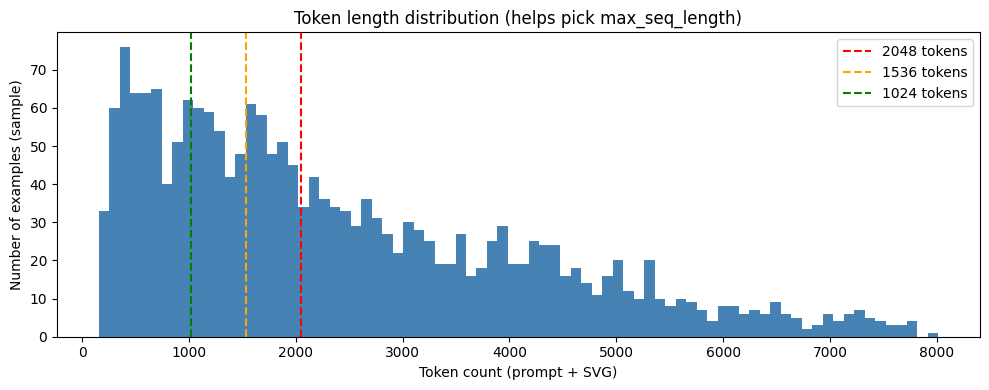

Fraction of sampled examples fitting within max_seq_length:
   1024 tokens: 25.2% of examples fit
   1536 tokens: 39.1% of examples fit
   2048 tokens: 52.5% of examples fit
   2560 tokens: 61.9% of examples fit
   3072 tokens: 69.5% of examples fit


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_lengths, bins=80, color="steelblue", edgecolor="none")
ax.axvline(2048, color="red",    linestyle="--", linewidth=1.5, label="2048 tokens")
ax.axvline(1536, color="orange", linestyle="--", linewidth=1.5, label="1536 tokens")
ax.axvline(1024, color="green",  linestyle="--", linewidth=1.5, label="1024 tokens")
ax.set_xlabel("Token count (prompt + SVG)")
ax.set_ylabel("Number of examples (sample)")
ax.set_title("Token length distribution (helps pick max_seq_length)")
ax.legend()
plt.tight_layout()
plt.show()

print("Fraction of sampled examples fitting within max_seq_length:")
for limit in [1024, 1536, 2048, 2560, 3072]:
    pct = 100 * (token_lengths <= limit).mean()
    print(f"  {limit:5d} tokens: {pct:.1f}% of examples fit")

### Observation: SVG tokenizes much worse than expected

Normal text tokenizes at about 1 token ≈ 4 characters
But looking at the statistics, it looks like 99th percentile are 7514 characters and 7320 tokens, which is much closer to 1 token = 1 character (4x less).

The reason could be that the Qwen tokenizer was trained primarily on natural language and general code, so it has efficient tokens for common English words and patterns, but SVG path data looks completely different. SVG paths have long sequences of decimal numbers like:

```
d="M93.30000305175781 21.20000457763672 L93.30000305175781 80.4..."
```

The tokenizer has no efficient representation for strings like `123.456`, so it splits each decimal number into individual digits and punctuation. According to Claude, this could look like:

```
"123.456"  →  ["123", ".", "4", "5", "6"]   ~= 5 tokens for 7 characters
```

This means with the `max_seq_length` of 2048 tokens, only 52.5% of examples fit from the 2k sampled, about half as many as expected.

This is a problem, because a truncated SVG in training actively harms the
model by teaching it that broken, incomplete SVGs are acceptable.

### **A Potential Solution**
Since this sub-pixel precision is likely visually not noticable but very expensive token-wise, going to try to round floating point coordinate decimal values before training.

## 10 Coordinate Rounding (Token Reduction)

As identified in Section 9, SVG path data tokenizes very inefficiently because
decimal coordinates like `123.456` get split into multiple tokens.

Objective is to round all floating point numbers in the SVG strings before training.
This should reduce token count without changing the visual output meaningfully.
We try both 1 decimal place and integer rounding to compare the tradeoff.

In [ ]:
import re

def round_svg_coordinates(svg_str: str, decimals: int = 1) -> str:
    """Round all floating point numbers in an SVG string.

    decimals=1 keeps one decimal place as a safety margin.
    decimals=0 rounds to integers for maximum token savings.
    """
    def round_match(m):
        value   = float(m.group(0))
        rounded = round(value, decimals)
        if decimals == 0:
            return str(int(rounded))
        return str(rounded)

    return re.sub(r'-?\d+\.\d+', round_match, svg_str)


# Demo: what does rounding actually do to one example?
original = train_df.loc[0, "svg"]
rounded  = round_svg_coordinates(original, decimals=1)

print(f"Original : {len(original):,} chars, {len(tokenizer.encode(original))} tokens")
print(f"Rounded  : {len(rounded):,} chars, {len(tokenizer.encode(rounded))} tokens")
print(f"\nSample of what changes:")
# Show a short snippet where rounding had an effect
orig_snippet   = original[200:350]
rounded_snippet = round_svg_coordinates(orig_snippet, decimals=1)
print(f"  Before: {orig_snippet}")
print(f"  After : {rounded_snippet}")

Original : 4,183 chars, 3916 tokens
Rounded  : 1,645 chars, 1378 tokens

Sample of what changes:
  Before: 30000305175781 80.4000015258789 L21.20000457763672 80.4000015258789 L21.20000457763672 179.60000610351562 L120.4000015258789 179.60000610351562 L120.4
  After : 30000305175781 80.4 L21.2 80.4 L21.2 179.6 L120.4 179.6 L120.4


In [ ]:
# Measure token reduction across the 2k sample
token_lengths_rounded = []
for _, row in sample_df.iterrows():
    rounded_svg = round_svg_coordinates(row["svg"], decimals=1)
    formatted   = format_training_example(SYSTEM_PROMPT, row["prompt"], rounded_svg)
    token_lengths_rounded.append(len(tokenizer.encode(formatted)))

token_lengths_rounded = np.array(token_lengths_rounded)

print("Token length comparison (2k sample):")
print(f"  {'Percentile':>10}  {'Before':>8}  {'After':>8}  {'Saved':>6}")
print("  " + "-" * 38)
for pct in [50, 75, 90, 95, 99]:
    before = np.percentile(token_lengths, pct)
    after  = np.percentile(token_lengths_rounded, pct)
    print(f"  p{pct:3d}        {before:>8.0f}  {after:>8.0f}  {before-after:>6.0f}")

before_pct = 100 * (token_lengths         <= 2048).mean()
after_pct  = 100 * (token_lengths_rounded <= 2048).mean()
print(f"\nFit within 2048 tokens: {before_pct:.1f}% -> {after_pct:.1f}% after rounding")

Token length comparison (2k sample):
  Percentile    Before     After   Saved
  --------------------------------------
  p 50            1934       921    1014
  p 75            3558      1418    2139
  p 90            5049      1943    3106
  p 95            5974      2279    3695
  p 99            7320      3021    4299

Fit within 2048 tokens: 52.5% -> 92.3% after rounding


### Observation: impact of coordinate rounding

The table above quantifies the token savings from rounding. Even rounding to
1 decimal place (keeping `123.5` instead of `123.456`) saves a meaningful number
of tokens per example, and the percentage fitting within 2048 increases significantly from 52.5% to 92.3%.

### Decision: Apply this to full dataset before saving & training! + Re-analyze lengths rounded SVGs

Get more accurate numbers for choosing max chararacters allowed to fit within 2048 tokens on the new rounded dataset.

In [ ]:
DECIMALS = 0 # round to x decimals

print("Applying coordinate rounding to full training set for analysis...")
train_df["svg_rounded"] = train_df["svg"].apply(
    lambda s: round_svg_coordinates(s, decimals=DECIMALS)
)
train_df["svg_len_rounded"] = train_df["svg_rounded"].str.len()

print(f"Done. Rounded {len(train_df):,} SVGs.")
print(f"\nCharacter length comparison (full dataset):")
print(f"  {'':10}  {'Original':>10}  {'Rounded':>10}  {'Saved':>8}")
print("  " + "-" * 44)
for pct in [50, 75, 90, 95, 99]:
    orig = train_df["svg_len"].quantile(pct/100)
    rnd  = train_df["svg_len_rounded"].quantile(pct/100)
    print(f"  p{pct:<7}    {orig:>10.0f}  {rnd:>10.0f}  {orig-rnd:>8.0f}")

Applying coordinate rounding to full training set for analysis...
Done. Rounded 50,000 SVGs.

Character length comparison (full dataset):
                Original     Rounded     Saved
  --------------------------------------------
  p50               2110         755      1355
  p75               3530        1103      2427
  p90               5100        1504      3596
  p95               6078        1754      4324
  p99               7514        2365      5149


In [ ]:
# How many examples survive at different character thresholds, using ROUNDED lengths?
# Compare this to the original numbers to see how many more samples can be kept with rounding

thresholds = [2000, 2500, 3000, 4000, 5000]

print(f"{'Threshold':>12}  {'Original kept':>14}  {'Rounded kept':>13}  {'Gain':>6}")
print("-" * 52)
for t in thresholds:
    orig_kept    = (train_df["svg_len"]         <= t).sum()
    rounded_kept = (train_df["svg_len_rounded"] <= t).sum()
    gain         = rounded_kept - orig_kept
    orig_pct     = 100 * orig_kept    / len(train_df)
    rounded_pct  = 100 * rounded_kept / len(train_df)
    print(f"{t:>12,}  {orig_kept:>8,} ({orig_pct:4.1f}%)  {rounded_kept:>7,} ({rounded_pct:4.1f}%)  +{gain:>5,}")

   Threshold   Original kept   Rounded kept    Gain
----------------------------------------------------
       2,000    23,757 (47.5%)   48,867 (97.7%)  +25,110
       2,500    29,082 (58.2%)   49,565 (99.1%)  +20,483
       3,000    33,568 (67.1%)   49,671 (99.3%)  +16,103
       4,000    40,315 (80.6%)   49,820 (99.6%)  +9,505
       5,000    44,683 (89.4%)   49,903 (99.8%)  +5,220


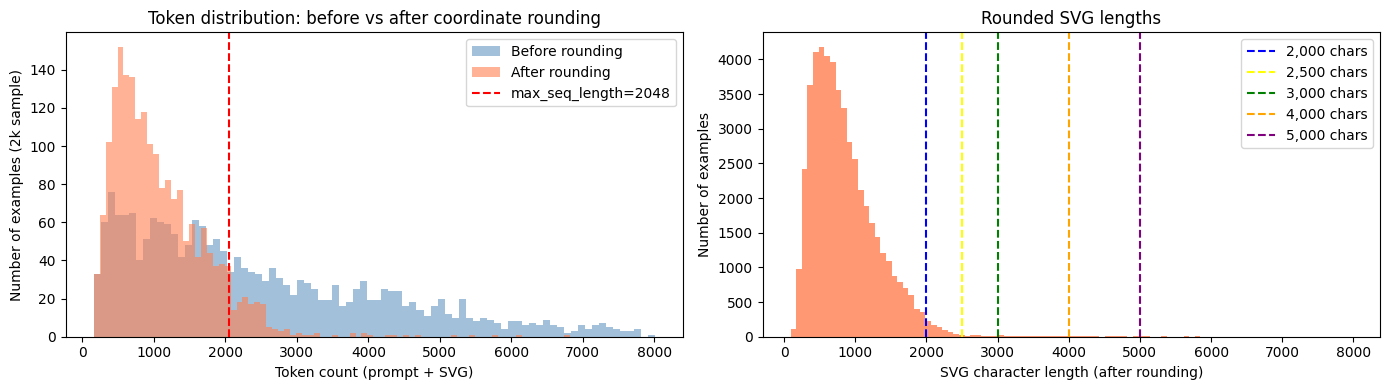

In [ ]:
# Plot 1: Token distribution before vs after rounding (on the 2k sample)
# Plot 2: Character length distribution of rounded SVGs with threshold candidates
# Both together help choose the right SVG_MAX_CHARS

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# plot 1
axes[0].hist(token_lengths,         bins=80, alpha=0.5, color="steelblue",
             label="Before rounding", edgecolor="none")
axes[0].hist(token_lengths_rounded, bins=80, alpha=0.6, color="coral",
             label="After rounding",  edgecolor="none")
axes[0].axvline(2048, color="red", linestyle="--", linewidth=1.5,
                label="max_seq_length=2048")
axes[0].set_xlabel("Token count (prompt + SVG)")
axes[0].set_ylabel("Number of examples (2k sample)")
axes[0].set_title("Token distribution: before vs after coordinate rounding")
axes[0].legend()

# plot 2
axes[1].hist(train_df[train_df["svg_len_rounded"] <= 8000]["svg_len_rounded"],
             bins=100, color="coral", edgecolor="none", alpha=0.8)
for thresh, color, label in [
    (2000, "blue",  "2,000"),
    (2500, "yellow",  "2,500"),
    (3000, "green",  "3,000"),
    (4000, "orange", "4,000"),
    (5000, "purple", "5,000"),
]:
    axes[1].axvline(thresh, color=color, linestyle="--", linewidth=1.5,
                    label=f"{label} chars")
axes[1].set_xlabel("SVG character length (after rounding)")
axes[1].set_ylabel("Number of examples")
axes[1].set_title("Rounded SVG lengths")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# What token lengths are at each character threshold?
# Want to pick a threshold where at least p95 tokens comfortably fits under 2048.

print("Token lengths at each character threshold (rounded SVGs, 500-sample estimate):\n")
print(f"  {'Char limit':>12}  {'Examples kept':>14}  {'p50 tok':>8}  {'p90 tok':>8}  {'p95 tok':>8}  {'% fit 2048':>11}")
print("  " + "-" * 70)

for char_limit in [2000, 2500, 3000, 4000, 5000]:
    subset = train_df[train_df["svg_len_rounded"] <= char_limit].sample(
        n=min(500, (train_df["svg_len_rounded"] <= char_limit).sum()),
        random_state=42
    )
    toks = []
    for _, row in subset.iterrows():
        fmt = format_training_example(SYSTEM_PROMPT, row["prompt"], row["svg_rounded"])
        toks.append(len(tokenizer.encode(fmt)))
    toks = np.array(toks)
    n_kept  = (train_df["svg_len_rounded"] <= char_limit).sum()
    pct_fit = 100 * (toks <= 2048).mean()
    print(f"  {char_limit:>12,}  {n_kept:>10,} ({100*n_kept/len(train_df):4.1f}%)  "
          f"{np.percentile(toks,50):>8.0f}  {np.percentile(toks,90):>8.0f}  "
          f"{np.percentile(toks,95):>8.0f}  {pct_fit:>9.1f}%")

Token lengths at each character threshold (rounded SVGs, 500-sample estimate):

    Char limit   Examples kept   p50 tok   p90 tok   p95 tok   % fit 2048
  ----------------------------------------------------------------------
         2,000      48,867 (97.7%)       634      1283      1480      100.0%
         2,500      49,565 (99.1%)       654      1193      1326       99.6%
         3,000      49,671 (99.3%)       669      1282      1477       99.6%
         4,000      49,820 (99.6%)       654      1304      1471       99.6%
         5,000      49,903 (99.8%)       630      1272      1523       99.2%


### Observation: Use token count rather than char chount

SVGs tokenize slightly unpredictably (doubling char limit doesn't double p95 tok). Could accidentally exceed token limit if just limiting on chararacter count.

### Decision: Filter the training dataset based on token count with prompt, rather than char length

## 11 Primitive Normalization (Token Reduction + Visual Improvement)

### Observation

Looking at early inference results, the model consistently spits out overly complicated paths.

For example, a prompt for a simple red circle came back as a 478 character long donut:



> Prompt       : a simple red circle on a white background

> Output length: 478 chars

> Valid SVG    : True

> SVG output:
`<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#E60013" fill-opacity="1.0"  filling="0" d="M100.0 184.4 C51.7 184.4 14.4 147.1 14.4 100.0 C14.4 52.9 51.7 15.6 100.0 15.6 C148.3 15.6 185.6 52.9 185.6 100.0 C185.6 147.1 148.3 184.4 100.0 184.4 Z M100.0 22.9 C57.1 22.9 22.9 57.1 22.9 100.0 C22.9 142.9 57.1 177.1 100.0 177.1 C142.9 177.1 177.1 142.9 177.1 100.0 C177.1 57.1 142.9 22.9 100.0 22.9 Z"></path></svg>`



This happens because the training data is heavily path-dominated (see Section 5: ~120k paths vs ~14k circles).
The model must have learned "SVG = paths".

### How this could be affecting our score

- **Visual fidelity (85% weight):** A path-encoded circle renders identically to `<circle>`,
  so V is unaffected. But for complex prompts, tokens spent on verbose path encoding are
  tokens *not* spent on actually drawing the subject (things could get left out). So compactness directly enables richer output.
- **Structural similarity (12% weight):** TED compares element trees. If a reference SVG
  uses `<circle>` and we output a bezier path, we would lose structural points even with perfect rendering.
  Normalizing training data toward primitives teaches the model to match the reference structure.
  
  If the reference uses a path and our model uses a circle, we lose some points, but hopefully what we would gain in visual fidelity (worth much higher %) would be worth it.
- **Compactness (3% weight):** `<circle cx="50" cy="50" r="40"/>` is ~30 chars.
  Its bezier equivalent is ~150+ chars. Token savings are significant.

### Strategy

For each `<path>` element, sample points along the path and check if they fit a known primitive's geometry within a tolerance. If yes, replace the path with the primitive
and copy over all style attributes (fill, stroke, opacity, etc).

Choosing key shapes that could be used to create a variety of more complex shapes and appear at least a few times in the dataset:

**circle**, **ellipse**, **rect**, **line**.


In [ ]:
%pip install -q svg.path

#### Primitive detection functions

In [ ]:
from svg.path import parse_path, CubicBezier, Line, Arc, Close, Move
import xml.etree.ElementTree as ET
import math, re
import numpy as np

TOLERANCE = 0.05  # 5% geometric tolerance (increase for more replacements, down for fewer/safer)

# point sampling
def sample_path_points(d: str, n: int = 120):
    """Sample n evenly-spaced points along a path d-string."""
    try:
        path = parse_path(d)
        segs = [s for s in path if not isinstance(s, (Move, Close))]
        if not segs:
            return []
        pts = []
        per = max(4, n // len(segs))
        for seg in segs:
            for t in np.linspace(0, 1, per):
                p = seg.point(t)
                pts.append((p.real, p.imag))
        return pts
    except Exception:
        return []

# primitive detectors
def detect_circle(d: str, tol: float = TOLERANCE):
    """Return (cx, cy, r) if path traces a complete circle, else None.

    Requires the path to be closed (ends near start) to avoid detecting
    circular arcs or partial outlines as full circles.
    """
    pts = sample_path_points(d, 120)
    if len(pts) < 8:
        return None
    xs, ys = zip(*pts)
    cx, cy = np.mean(xs), np.mean(ys)
    dists  = [math.hypot(x - cx, y - cy) for x, y in pts]
    r      = np.mean(dists)
    if r < 1e-3:
        return None

    # All points must be close to the radius
    if max(abs(d_ - r) / r for d_ in dists) > tol:
        return None

    # Must be circular not elliptical
    w, h = max(xs) - min(xs), max(ys) - min(ys)
    if abs(w - h) / max(w, h, 1e-6) > tol:
        return None

    # Path must be closed (first and last points close together)
    # An open arc would fail this check
    start_end_dist = math.hypot(pts[0][0] - pts[-1][0], pts[0][1] - pts[-1][1])
    if start_end_dist > r * 0.15:
        return None

    # Angular coverage (points must span close to 360 degrees)
    # Catches partial arcs that happen to fit a circle radius
    angles = sorted([math.atan2(y - cy, x - cx) for x, y in pts])
    gaps   = [angles[i+1] - angles[i] for i in range(len(angles)-1)]
    gaps.append((angles[0] + 2*math.pi) - angles[-1])  # wrap-around gap
    if max(gaps) > math.pi * 0.4:  # any gap > 72 degrees means incomplete arc
        return None

    return round(cx, 1), round(cy, 1), round(r, 1)

def detect_ellipse(d: str, tol: float = TOLERANCE):
    """Return (cx, cy, rx, ry) if path is an ellipse, else None."""
    pts = sample_path_points(d, 120)
    if len(pts) < 8:
        return None
    xs, ys = zip(*pts)
    cx, cy = np.mean(xs), np.mean(ys)
    rx = (max(xs) - min(xs)) / 2
    ry = (max(ys) - min(ys)) / 2
    if rx < 1e-3 or ry < 1e-3:
        return None
    errors = [abs(((x - cx) / rx) ** 2 + ((y - cy) / ry) ** 2 - 1.0) for x, y in pts]
    if max(errors) > tol * 4:
        return None
    return round(cx, 1), round(cy, 1), round(rx, 1), round(ry, 1)

def detect_rect(d: str, tol: float = TOLERANCE):
    """Return (x, y, w, h) if path is a simple rectangle, else None.

    Increasing strictness: requires that essentially all sampled points
    lie exactly on one of the four edges, and that the path has few segments.
    This prevents complex icons from being collapsed to their bounding box.
    """
    pts = sample_path_points(d, 200)
    if len(pts) < 4:
        return None
    xs, ys = zip(*pts)
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    w, h = x1 - x0, y1 - y0
    if w < 1e-3 or h < 1e-3:
        return None

    # Each point must lie very close to one of the four edges
    # (not just within the bounding box but actually ON the edges)
    edge_tol = tol * max(w, h)
    def on_an_edge(px, py):
        on_left   = abs(px - x0) < edge_tol
        on_right  = abs(px - x1) < edge_tol
        on_top    = abs(py - y0) < edge_tol
        on_bottom = abs(py - y1) < edge_tol
        return on_left or on_right or on_top or on_bottom

    if not all(on_an_edge(x, y) for x, y in pts):
        return None

    # All four edges must be represented (catches L-shapes or single lines)
    has_left   = any(abs(x - x0) < edge_tol for x, y in pts)
    has_right  = any(abs(x - x1) < edge_tol for x, y in pts)
    has_top    = any(abs(y - y0) < edge_tol for x, y in pts)
    has_bottom = any(abs(y - y1) < edge_tol for x, y in pts)
    if not (has_left and has_right and has_top and has_bottom):
        return None

    # Path must be closed
    start_end_dist = math.hypot(pts[0][0] - pts[-1][0], pts[0][1] - pts[-1][1])
    if start_end_dist > max(w, h) * 0.1:
        return None

    return round(x0, 1), round(y0, 1), round(w, 1), round(h, 1)

def detect_line(d: str, tol: float = TOLERANCE):
    """Return (x1, y1, x2, y2) if path is a straight line, else None."""
    pts = sample_path_points(d, 60)
    if len(pts) < 2:
        return None
    xs, ys = zip(*pts)
    x0, y0, x1, y1 = xs[0], ys[0], xs[-1], ys[-1]
    length = math.hypot(x1 - x0, y1 - y0)
    if length < 1e-3:
        return None
    def line_dist(px, py):
        return abs((y1-y0)*px - (x1-x0)*py + x1*y0 - y1*x0) / length
    if pts[1:-1] and max(line_dist(x, y) for x, y in pts[1:-1]) > tol * length:
        return None
    return round(x0, 1), round(y0, 1), round(x1, 1), round(y1, 1)

# attribute transfer
STYLE_ATTRS = {
    "fill", "fill-opacity", "fill-rule", "stroke", "stroke-width",
    "stroke-opacity", "stroke-linecap", "stroke-linejoin",
    "stroke-dasharray", "opacity", "transform", "style"
}

def copy_style_attrs(src, dst):
    for k, v in src.attrib.items():
        if k in STYLE_ATTRS:
            dst.set(k, v)

# per-element replacement
def try_replace_path(elem):
    """Try to replace a <path> element with a simpler primitive.

    Additional guard: only replace if the path is filled (not just stroked).
    A stroked-only path like a circle outline should stay as a path since
    converting to <circle fill='none' stroke='...'> risks subtle rendering
    differences and loses the original path's visual character.
    """
    d = elem.attrib.get("d", "").strip()
    if not d:
        return None

    # Check fill (skip replacement for stroke-only paths)
    fill   = elem.attrib.get("fill", "").strip().lower()
    stroke = elem.attrib.get("stroke", "").strip().lower()
    is_stroke_only = (fill in ("none", "") and stroke not in ("none", ""))

    # Also check inline style for fill:none
    style = elem.attrib.get("style", "")
    if "fill:none" in style.replace(" ", "") or "fill: none" in style:
        is_stroke_only = True

    if is_stroke_only:
        return None  # don't convert outlines to filled primitives

    result = detect_circle(d)
    if result:
        cx, cy, r = result
        new = ET.Element("circle")
        new.set("cx", str(cx)); new.set("cy", str(cy)); new.set("r", str(r))
        copy_style_attrs(elem, new)
        return new

    result = detect_ellipse(d)
    if result:
        cx, cy, rx, ry = result
        new = ET.Element("ellipse")
        new.set("cx", str(cx)); new.set("cy", str(cy))
        new.set("rx", str(rx)); new.set("ry", str(ry))
        copy_style_attrs(elem, new)
        return new

    result = detect_rect(d)
    if result:
        x, y, w, h = result
        new = ET.Element("rect")
        new.set("x", str(x)); new.set("y", str(y))
        new.set("width", str(w)); new.set("height", str(h))
        copy_style_attrs(elem, new)
        return new

    result = detect_line(d)
    if result:
        x1, y1, x2, y2 = result
        new = ET.Element("line")
        new.set("x1", str(x1)); new.set("y1", str(y1))
        new.set("x2", str(x2)); new.set("y2", str(y2))
        copy_style_attrs(elem, new)
        return new

    return None

# full SVG normalizer
def normalize_primitives(svg_str: str):
    """
    Walk the SVG tree and replace path elements with primitives where possible.
    Returns (new_svg_str, stats_dict).
    """
    stats = {"circle": 0, "ellipse": 0, "rect": 0, "line": 0, "unchanged": 0}
    try:
        if 'xmlns=' not in svg_str:
            svg_str = svg_str.replace('<svg', '<svg xmlns="http://www.w3.org/2000/svg"', 1)
        root = ET.fromstring(svg_str)
    except ET.ParseError:
        return svg_str, stats

    def walk(parent):
        for i, child in enumerate(list(parent)):
            tag = child.tag.split("}")[-1] if "}" in child.tag else child.tag
            if tag == "path":
                replacement = try_replace_path(child)
                if replacement is not None:
                    replacement.tail = child.tail
                    parent[i] = replacement
                    stats[replacement.tag] += 1
                else:
                    stats["unchanged"] += 1
            else:
                walk(child)

    walk(root)
    ET.register_namespace("", "http://www.w3.org/2000/svg")
    return ET.tostring(root, encoding="unicode"), stats

# SAFE VERSION: only replace if token count is reduced
def normalize_primitives_safe(svg_str: str, tokenizer) -> str:
    """Apply primitive normalization only if it reduces token count.

    The standard normalize_primitives occasionally produced worse output
    when the detection heuristics misidentify a complex path as a simple shape.
    This wrapper measures token count before and after, and reverts to the
    original if the replacement increased tokens.
    """
    new_svg, stats = normalize_primitives(svg_str)

    # Only accept if at least one replacement was made
    replaced = sum(stats[k] for k in ["circle", "ellipse", "rect", "line"])
    if replaced == 0:
        return svg_str  # nothing changed, skip tokenization overhead

    # Revert if tokens increased
    tok_before = len(tokenizer.encode(svg_str))
    tok_after  = len(tokenizer.encode(new_svg))

    return new_svg if tok_after <= tok_before else svg_str

print("Primitive normalization functions loaded.")
print(f"Tolerance: {TOLERANCE*100:.0f}%")


Primitive normalization functions loaded.
Tolerance: 5%


#### Measure conversion rate and token savings on a sample

In [ ]:
PRIM_SAMPLE_SIZE = min(2000, len(train_df))
prim_idx    = np.random.RandomState(42).choice(len(train_df), PRIM_SAMPLE_SIZE, replace=False)
prim_sample = train_df.iloc[prim_idx].copy()

results      = []

for _, row in prim_sample.iterrows():
    # Use the already-rounded SVG as input so savings are additive
    orig = row.get("svg_rounded", row["svg"])
    new_svg = normalize_primitives_safe(orig, tokenizer)

    tok_before = len(tokenizer.encode(orig))
    tok_after  = len(tokenizer.encode(new_svg))
    changed    = orig != new_svg  # True if any replacement was accepted

    results.append({
        "original_svg": orig,
        "new_svg":      new_svg,
        "tok_before":   tok_before,
        "tok_after":    tok_after,
        "tok_saved":    tok_before - tok_after,
        "changed":      changed,
    })

results_df = pd.DataFrame(results)
changed_df = results_df[results_df["changed"]]

print(f"\n── Token savings (changed SVGs only, n={len(changed_df)}) ──────────")
tok_b  = changed_df["tok_before"].values
tok_a  = changed_df["tok_after"].values
saved  = changed_df["tok_saved"].values

print(f"  {'Metric':12}  {'Before':>8}  {'After':>8}  {'Saved':>7}")
print("  " + "─" * 42)
for label, b, a, s in [
    ("Mean",   tok_b.mean(),            tok_a.mean(),            saved.mean()),
    ("Median", np.median(tok_b),        np.median(tok_a),        np.median(saved)),
    ("p90",    np.percentile(tok_b,90), np.percentile(tok_a,90), np.percentile(saved,90)),
    ("p99",    np.percentile(tok_b,99), np.percentile(tok_a,99), np.percentile(saved,99)),
]:
    print(f"  {label:12}  {b:>8.0f}  {a:>8.0f}  {s:>7.0f}")

print(f"\n  SVGs where token count increased (bad replacements): {(saved < 0).sum()}")



── Token savings (changed SVGs only, n=366) ──────────
  Metric          Before     After    Saved
  ──────────────────────────────────────────
  Mean               884       758      126
  Median             838       679       90
  p90               1441      1244      295
  p99               2446      2318      666

  SVGs where token count increased (bad replacements): 0


#### Visual check: before vs after side by side

In [ ]:
from IPython.display import display, HTML
import random

N_VISUAL = 8
visual_sample = changed_df.sample(min(N_VISUAL, len(changed_df)), random_state=42)

for _, row in visual_sample.iterrows():
    saved_tok = row["tok_before"] - row["tok_after"]
    display(HTML(f"""
    <div style='display:flex;gap:32px;align-items:center;margin:10px 0;
                border-bottom:1px solid #eee;padding-bottom:10px;font-family:monospace'>
      <div style='text-align:center'>
        <div style='font-size:11px;color:#888;margin-bottom:4px'>
          BEFORE ({row['tok_before']} tok)</div>
        {row['original_svg']}
      </div>
      <div style='font-size:20px;color:#aaa'>→</div>
      <div style='text-align:center'>
        <div style='font-size:11px;color:#888;margin-bottom:4px'>
          AFTER ({row['tok_after']} tok, saved {saved_tok})</div>
        {row['new_svg']}
      </div>
    </div>
    """))


### Decision: DO NOT primitive normalization to full dataset

On examples where icons are contained inside simple shapes, the converters struggle. Even after trying to put in some guards and fix it, a few rare examples fall through. There appears to be too much visual fidelity lost, with not enough token savings to make it worth it.


In [ ]:
# Primitive normalization removed :( visual information loss outweighs token savings
# Coordinate rounding (svg_rounded) provides sufficient token reduction.
# svg_normalized is set equal to svg_rounded so the column chain stays intact.

train_df["svg_normalized"] = train_df["svg_rounded"]
print("Primitive normalization skipped...using svg_rounded directly.")


# print("Applying primitive normalization to full training set...")
# print("(This may take a few minutes...parsing every SVG)")

# norm_svgs  = []

# for svg in train_df["svg_rounded"]:
#     new_svg, stats = normalize_primitives(svg, tokenizer)
#     norm_svgs.append(new_svg)

# train_df["svg_normalized"] = norm_svgs

# # Character length comparison
# orig_chars = train_df["svg_rounded"].str.len()
# norm_chars = train_df["svg_normalized"].str.len()
# print(f"\nCharacter length: {orig_chars.mean():.0f} → {norm_chars.mean():.0f} mean "
#       f"(saved {(orig_chars - norm_chars).mean():.1f} chars/SVG on average)")


Primitive normalization skipped...using svg_rounded directly.


## 12 Remove Duplicates

We found 4069 duplicated prompts in the data. This might create conflicting gradients for the same prompt during training, causing the model to learn to average those outputs rather than produce any single clean SVG and leading to very generic outputs.

In [ ]:
# Count the scale of the problem
prompt_counts = train_df["prompt"].value_counts()
print(f"Total rows: {len(train_df)}")
print(f"Unique prompts: {len(prompt_counts)}")
print(f"Prompts appearing more than once: {(prompt_counts > 1).sum()}")
print(f"Max repeats for a single prompt: {prompt_counts.max()}")
print(f"\nDistribution of prompt frequency:")
print(prompt_counts.value_counts().sort_index().head(10))

# Deduplicate: keep the shortest SVG per prompt
original_len = len(train_df)
train_df["svg_len"] = train_df["svg"].str.len()
train_df = train_df.sort_values("svg_len").drop_duplicates(subset=["prompt"], keep="first")
train_df = train_df.drop(columns=["svg_len"])

print(f"\nAfter deduplication: {len(train_df)} rows (dropped {original_len - len(train_df)})")

Total rows: 50000
Unique prompts: 45931
Prompts appearing more than once: 1071
Max repeats for a single prompt: 1788

Distribution of prompt frequency:
count
1     44860
2       653
3       203
4        82
5        39
6        25
7        18
8        14
9         7
10        1
Name: count, dtype: int64

After deduplication: 45931 rows (dropped 4069)


## 13 SVG Attribute Cleaning & Outlier Removal

Now that coordinates are rounded and paths are normalized, we apply a set of
lossless SVG simplifications to further reduce token count, followed by
outlier removal to cut low-signal training examples.

### 13.1 Lossless attribute cleaning

Remove attributes that are redundant (SVG default values), irrelevant to rendering,
or wasteful of tokens:

| Attribute | Default / reason to drop |
|---|---|
| `fill-opacity="1"` | SVG default |
| `stroke="none"` | SVG default when no stroke |
| `stroke-width="1"` | SVG default |
| `display="inline"` | SVG default |
| `visibility="visible"` | SVG default |
| `fill-rule="nonzero"` | SVG default |
| `id=`, `class=`, `data-*`, `aria-*` | Not used by renderer |
| `xmlns=` on child elements | Only needed on root `<svg>` |
| `width=`/`height=` on root `<svg>` | Redundant if `viewBox` present |
| Long hex colors | `#ffffff` → `#fff`, `#ff0000` → `#f00` |
| Empty `<g>` groups | No visual effect |


In [ ]:
import re

# Redundant default attribute values — safe to strip
REDUNDANT_ATTRS = {
    "fill-opacity":  "1",
    "stroke":        "none",
    "stroke-width":  "1",
    "display":       "inline",
    "visibility":    "visible",
    "fill-rule":     "nonzero",
    "stroke-opacity":"1",
    "stroke-linecap":"butt",
    "stroke-linejoin":"miter",
}

# Attributes that carry no rendering info
DROP_ATTRS = {"id", "class", "data-name", "xml:space"}

# Hex color shortening: #rrggbb → #rgb when all pairs match
def shorten_hex(m):
    h = m.group(0)
    if len(h) == 7:
        r, g, b = h[1:3], h[3:5], h[5:7]
        if r[0]==r[1] and g[0]==g[1] and b[0]==b[1]:
            return f"#{r[0]}{g[0]}{b[0]}"
    return h

HEX_RE = re.compile(r'#[0-9a-fA-F]{6}')

def clean_svg_attributes(svg_str: str) -> str:
    """
    Apply lossless attribute cleaning to an SVG string:
    - Remove redundant default attributes
    - Remove non-rendering attributes (id, class, data-*)
    - Drop width/height from root <svg> if viewBox present
    - Shorten #rrggbb hex colors to #rgb where possible
    - Remove empty <g> groups
    """
    try:
        if 'xmlns=' not in svg_str:
            svg_str = svg_str.replace('<svg', '<svg xmlns="http://www.w3.org/2000/svg"', 1)
        root = ET.fromstring(svg_str)
    except ET.ParseError:
        return svg_str

    def clean_elem(elem):
        tag = elem.tag.split("}")[-1] if "}" in elem.tag else elem.tag

        # Commenting this out because it was actually changing size of the svg
        # Drop root width/height if viewBox is present
        # if tag == "svg" and "viewBox" in elem.attrib:
        #     elem.attrib.pop("width",  None)
        #     elem.attrib.pop("height", None)

        # Remove redundant default attrs
        for attr, default_val in REDUNDANT_ATTRS.items():
            if elem.attrib.get(attr) == default_val:
                del elem.attrib[attr]

        # Remove non-rendering attrs
        for attr in list(elem.attrib):
            local = attr.split("}")[-1] if "}" in attr else attr
            if local in DROP_ATTRS or local.startswith("data-") or local.startswith("aria-"):
                del elem.attrib[attr]

        # Remove xmlns declarations on non-root elements
        if tag != "svg":
            for attr in list(elem.attrib):
                if "xmlns" in attr:
                    del elem.attrib[attr]

        # Shorten hex colors in all attribute values
        for attr, val in list(elem.attrib.items()):
            elem.attrib[attr] = HEX_RE.sub(shorten_hex, val)

        # Recurse, then remove empty <g> groups
        for child in list(elem):
            clean_elem(child)

        for child in list(elem):
            child_tag = child.tag.split("}")[-1] if "}" in child.tag else child.tag
            if child_tag == "g" and len(child) == 0 and not child.text:
                elem.remove(child)

    clean_elem(root)
    ET.register_namespace("", "http://www.w3.org/2000/svg")
    return ET.tostring(root, encoding="unicode")

# only replace if tokens are reduced
def clean_svg_attributes_safe(svg_str: str, tokenizer) -> str:
    cleaned = clean_svg_attributes(svg_str)
    if len(tokenizer.encode(cleaned)) <= len(tokenizer.encode(svg_str)):
        return cleaned
    return svg_str

# measure savings on sample
clean_sample = train_df["svg_normalized"].sample(2000, random_state=42)

tok_before_clean = [len(tokenizer.encode(s)) for s in clean_sample]
cleaned          = [clean_svg_attributes_safe(s, tokenizer) for s in clean_sample]
tok_after_clean  = [len(tokenizer.encode(s)) for s in cleaned]

tb = np.array(tok_before_clean)
ta = np.array(tok_after_clean)
saved = tb - ta

print("Attribute cleaning token savings (2k sample)")
print(f"  {'Metric':12}  {'Before':>8}  {'After':>8}  {'Saved':>7}")
print("  " + "─" * 42)
for label, b, a, s in [
    ("Mean",   tb.mean(),            ta.mean(),            saved.mean()),
    ("Median", np.median(tb),        np.median(ta),        np.median(saved)),
    ("p90",    np.percentile(tb,90), np.percentile(ta,90), np.percentile(saved,90)),
    ("p99",    np.percentile(tb,99), np.percentile(ta,99), np.percentile(saved,99)),
]:
    print(f"  {label:12}  {b:>8.0f}  {a:>8.0f}  {s:>7.0f}")
print(f"\n  Examples where tokens increased: {(saved < 0).sum()}")


Attribute cleaning token savings (2k sample)
  Metric          Before     After    Saved
  ──────────────────────────────────────────
  Mean               690       675       14
  Median             588       577        7
  p90               1218      1190       30
  p99               1868      1821       77

  Examples where tokens increased: 0


In [ ]:
N_VISUAL = 8
sample_indices = clean_sample.index[:N_VISUAL]

for idx in sample_indices:
    before = clean_sample[idx]
    after  = cleaned[clean_sample.index.get_loc(idx)]
    tok_b  = len(tokenizer.encode(before))
    tok_a  = len(tokenizer.encode(after))

    display(HTML(f"""
    <div style='display:flex;gap:32px;align-items:center;margin:10px 0;
                border-bottom:1px solid #eee;padding-bottom:10px'>
      <div style='text-align:center'>
        <div style='font-size:11px;color:#888'>BEFORE ({tok_b} tok)</div>
        {before}
      </div>
      <div style='font-size:20px;color:#aaa'>→</div>
      <div style='text-align:center'>
        <div style='font-size:11px;color:#888'>AFTER ({tok_a} tok, saved {tok_b-tok_a})</div>
        {after}
      </div>
    </div>
    """))

### Decision: apply attribute cleaning to full dataset

All examples seem to visually stay the same. It doesn't save too many tokens, but hopefully prevents the model from learning unnecessary elements.

In [ ]:
# Apply attribute cleaning to the full dataset
print("Applying attribute cleaning to full dataset...")
#train_df["svg_clean"] = train_df["svg_normalized"].apply(clean_svg_attributes)
train_df["svg_clean"] = train_df["svg_normalized"].apply(
    lambda s: clean_svg_attributes_safe(s, tokenizer)
)
orig_chars  = train_df["svg_normalized"].str.len()
clean_chars = train_df["svg_clean"].str.len()
print(f"Done.")
print(f"Mean char length: {orig_chars.mean():.0f} → {clean_chars.mean():.0f} "
      f"(saved {(orig_chars - clean_chars).mean():.1f} chars/SVG)")


Applying attribute cleaning to full dataset...
Done.
Mean char length: 874 → 829 (saved 44.9 chars/SVG)


### 13.2 Outlier removal

Remove training examples that are unlikely to help the model learn and may
actively hurt by teaching bad patterns or wasting training budget.

**Filters:**

1. **High path count**: SVGs with >64 paths are nearly unlearnable and teach the model that SVGs should be very long.
2. **Prompt-SVG length mismatch**: A long detailed prompt paired with a tiny SVG (or vice versa) is usually a bad pair. Filter on the ratio.
3. **Degenerate SVGs**: Single solid-fill rectangle covering the full canvas. Zero visual learning signal.
4. **Vague prompts**: Prompts under 5 words provide no visual description to learn from.

In [ ]:
# degenerate helper function
def is_degenerate(svg_str: str) -> bool:
    """Return True if SVG is just a single solid-colour rectangle filling the canvas.

    These examples have zero visual learning signal — the model just learns
    to output a blank canvas for any prompt, which scores very low.
    """
    try:
        # Add namespace if missing so ET can parse it
        parse_str = svg_str
        if 'xmlns=' not in svg_str:
            parse_str = svg_str.replace('<svg', '<svg xmlns="http://www.w3.org/2000/svg"', 1)
        root = ET.fromstring(parse_str)

        # Get meaningful children (ignore metadata tags)
        children = [
            c for c in root
            if (c.tag.split("}")[-1] if "}" in c.tag else c.tag)
            not in ("defs", "title", "desc")
        ]

        # Must have exactly one child and it must be a rect
        if len(children) != 1:
            return False
        tag = children[0].tag.split("}")[-1] if "}" in children[0].tag else children[0].tag
        if tag != "rect":
            return False

        # Rect must cover >= 95% of the canvas
        r = children[0]
        x = float(r.attrib.get("x", 0))
        y = float(r.attrib.get("y", 0))
        w = float(r.attrib.get("width",  0))
        h = float(r.attrib.get("height", 0))
        vb = root.attrib.get("viewBox", "")
        if vb:
            vb_vals   = [float(v) for v in vb.split()]
            canvas_w  = vb_vals[2]
            canvas_h  = vb_vals[3]
            return (x <= 0 and y <= 0
                    and w >= canvas_w * 0.95
                    and h >= canvas_h * 0.95)

    except Exception:
        pass
    return False


print("is_degenerate() defined.")

is_degenerate() defined.


In [ ]:
# Each filter writes a boolean column to train_df.
# True = this example should be removed.
# Having separate columns lets us audit each filter independently
# and re-run any single filter without affecting others.

# Filter 1: high path count
PATH_COUNT_LIMIT = 64
train_df["filter_high_path"] = train_df["svg_clean"].apply(count_paths) > PATH_COUNT_LIMIT
print(f"Filter 1 (path count > {PATH_COUNT_LIMIT})     : {train_df['filter_high_path'].sum():,} flagged")

# Filter 2: prompt-SVG length mismatch
svg_chars    = train_df["svg_clean"].str.len()
prompt_chars = train_df["prompt_len"]
train_df["filter_mismatch"] = (
    ((prompt_chars > 100) & (svg_chars < 200)) |
    ((prompt_chars < 30)  & (svg_chars > 2000))
)
print(f"Filter 2 (length mismatch)           : {train_df['filter_mismatch'].sum():,} flagged")

# Filter 3: degenerate SVGs (single solid-fill rect covering full canvas)
train_df["filter_degenerate"] = train_df["svg_clean"].apply(is_degenerate)
print(f"Filter 3 (degenerate single-rect)    : {train_df['filter_degenerate'].sum():,} flagged")

# Filter 4: vague prompts
MIN_PROMPT_WORDS = 5
train_df["filter_vague_prompt"] = train_df["prompt_words"] < MIN_PROMPT_WORDS
print(f"Filter 4 (prompt under {MIN_PROMPT_WORDS} words)     : {train_df['filter_vague_prompt'].sum():,} flagged")

# Combined outlier flag — True means remove
train_df["is_outlier"] = (
    train_df["filter_high_path"]    |
    train_df["filter_mismatch"]     |
    train_df["filter_degenerate"]   |
    train_df["filter_vague_prompt"]
)

print(f"\nTotal flagged as outliers : {train_df['is_outlier'].sum():,}")
print(f"Examples remaining        : {(~train_df['is_outlier']).sum():,}")
print(f"Retention rate            : {100*(~train_df['is_outlier']).mean():.1f}%")

train_clean = train_df[~train_df["is_outlier"]].copy()


Filter 1 (path count > 64)     : 5 flagged
Filter 2 (length mismatch)           : 133 flagged
Filter 3 (degenerate single-rect)    : 4 flagged
Filter 4 (prompt under 5 words)     : 95 flagged

Total flagged as outliers : 230
Examples remaining        : 45,701
Retention rate            : 99.5%


## 14 Choose max_seq_length, SYSTEM_PROMPT, Token counting

### System prompt candidates

The system prompt is a fixed token cost on every single training example.
It also directly shapes how the model constructs SVGs at inference time.

We compare three candidates that reflect different design philosophies:

| Candidate | Philosophy |
|---|---|
| **A: Minimal** | Short, low token cost. Tells model what to output, not how. |
| **B: Constructive** | Medium length. Explicitly lists primitive elements and compositional strategy. |
| **C: Detailed** | Longer. Adds viewBox normalization and explicit background rule. |

The key insight from our analysis: the original prompt was output-format focused (no markdown, no comments) but gave zero guidance on *how to construct shapes*.

Candidate B and C add the construction strategy that should help with complex prompts like 'a blue bird icon' or 'firewood stack with leaf'.

Measure token cost of each candidate because the system prompt is used on ever training example (for example a 20-token difference across 45k examples is 900k tokens).


In [ ]:
# system prompt candidates
SYSTEM_PROMPT_A = (
    "You are an SVG code generator. "
    "Given a visual description, return only valid SVG code with a single root <svg> element. "
    "Output SVG code only — no explanation, no markdown, no comments."
)

SYSTEM_PROMPT_B = (
    "You are an SVG code generator. "
    "Given a visual description, output only valid SVG code. "
    "Use semantic SVG elements: <circle> for circles, <rect> for rectangles, "
    "<ellipse> for ovals, <line> for straight lines, <polygon> for angular shapes, "
    "<path> for curves and complex outlines. "
    "Build complex objects by composing multiple simple shapes. "
    "Use white background unless specified otherwise. "
    "Output SVG code only — no explanation, no markdown, no comments."
)

SYSTEM_PROMPT_C = (
    "You are an SVG code generator. "
    "Given a visual description, output only valid SVG code with a single root <svg> element. "
    "Use viewBox='0 0 100 100' and omit width/height attributes. "
    "Use semantic SVG elements: <circle> for circles, <rect> for rectangles, "
    "<ellipse> for ovals, <line> for lines, <polygon> for angular shapes, "
    "<path> for curves and complex outlines. "
    "Build complex objects by composing multiple simple shapes. "
    "Use white background (<rect width='100' height='100' fill='white'/>) unless specified otherwise. "
    "Center all content within the canvas. "
    "Output SVG code only — no explanation, no markdown, no comments."
)

candidates = {
    "A: Minimal":      SYSTEM_PROMPT_A,
    "B: Constructive": SYSTEM_PROMPT_B,
    "C: Detailed":     SYSTEM_PROMPT_C,
}

# measure token cost of each candidate
print("System prompt token costs")
print(f"  {'Candidate':22}  {'Chars':>6}  {'Tokens':>7}")
print("  " + "─" * 40)
for name, prompt in candidates.items():
    # The system prompt is a fixed cost added to every single training example.
    # Measure it once here to get the baseline before any prompt or SVG is added.

    # Full chat template overhead with just the system prompt (no user/SVG content)
    system_only = tokenizer.apply_chat_template(
        [{"role": "system", "content": prompt}],
        tokenize=False
    )
    system_only_tokens = len(tokenizer.encode(system_only))

    # Chat template with empty user and assistant turns (shows template overhead)
    template_shell = tokenizer.apply_chat_template(
        [
            {"role": "system",    "content": ""},
            {"role": "user",      "content": ""},
            {"role": "assistant", "content": ""},
        ],
        tokenize=False
    )
    template_shell_tokens = len(tokenizer.encode(template_shell))
    template_overhead      = template_shell_tokens  # tokens from special tokens + role labels alone

    system_content_tokens  = system_only_tokens - template_overhead
    print(f"  {name:22}  {len(prompt):>6}  {system_content_tokens:>7}")

print()
print("Key differences")
print("  A: No construction guidance. Shortest. Model must infer all structure.")
print("  B: Lists primitive elements + compositional strategy. Medium cost.")
print("  C: Adds viewBox normalization + explicit background. Highest cost.")


System prompt token costs
  Candidate                Chars   Tokens
  ────────────────────────────────────────
  A: Minimal                 184       30
  B: Constructive            449       85
  C: Detailed                619      140

Key differences
  A: No construction guidance. Shortest. Model must infer all structure.
  B: Lists primitive elements + compositional strategy. Medium cost.
  C: Adds viewBox normalization + explicit background. Highest cost.


### Decision: Use System Prompt B

Balance between giving information on how to construct without getting too long and detailed.

Would love to be able to test each of the prompts, but GPU aint free! We do know that prompt A didn't work great, so hoping prompt B will be better.

In [ ]:
# Set the chosen system prompt for all downstream token counting
FINAL_SYSTEM_PROMPT = SYSTEM_PROMPT_B

print(f"Using system prompt: {len(FINAL_SYSTEM_PROMPT)} chars")
print(FINAL_SYSTEM_PROMPT)


Using system prompt: 449 chars
You are an SVG code generator. Given a visual description, output only valid SVG code. Use semantic SVG elements: <circle> for circles, <rect> for rectangles, <ellipse> for ovals, <line> for straight lines, <polygon> for angular shapes, <path> for curves and complex outlines. Build complex objects by composing multiple simple shapes. Use white background unless specified otherwise. Output SVG code only — no explanation, no markdown, no comments.


In [ ]:
# The system prompt is a fixed cost added to every single training example.
# Measure it once here to get the baseline before any prompt or SVG is added.

# Full chat template overhead with just the system prompt (no user/SVG content)
system_only = tokenizer.apply_chat_template(
    [{"role": "system", "content": FINAL_SYSTEM_PROMPT}],
    tokenize=False
)
system_only_tokens = len(tokenizer.encode(system_only))

# Chat template with empty user and assistant turns (shows template overhead)
template_shell = tokenizer.apply_chat_template(
    [
        {"role": "system",    "content": ""},
        {"role": "user",      "content": ""},
        {"role": "assistant", "content": ""},
    ],
    tokenize=False
)
template_shell_tokens = len(tokenizer.encode(template_shell))
template_overhead      = template_shell_tokens  # tokens from special tokens + role labels alone

system_content_tokens  = system_only_tokens - template_overhead

print("Fixed token costs per training example:\n")
print(f"  Chat template special tokens : {template_overhead} tokens")
print(f"  System prompt content        : {system_content_tokens} tokens")
print(f"  Total fixed baseline         : {system_only_tokens} tokens")
print()
print(f"  Every example starts with {system_only_tokens} tokens before")
print(f"  the user prompt and SVG are added.")
print()

# Show what's left for prompt + SVG given a target max_seq_length
for seq_len in [2048, 3072, 4096]:
    remaining = seq_len - system_only_tokens
    print(f"  At max_seq_length={seq_len}: {remaining} tokens left for prompt + SVG")

Fixed token costs per training example:

  Chat template special tokens : 15 tokens
  System prompt content        : 85 tokens
  Total fixed baseline         : 100 tokens

  Every example starts with 100 tokens before
  the user prompt and SVG are added.

  At max_seq_length=2048: 1948 tokens left for prompt + SVG
  At max_seq_length=3072: 2972 tokens left for prompt + SVG
  At max_seq_length=4096: 3996 tokens left for prompt + SVG


### How many tokens for each sample (system prompt + user prompt + svg + chat template) in training?

NOTE! Evaluating using NEW prompt choice!

In [ ]:
# Compute token counts for the FULL dataset, included the system and user prompts + chat formatting things
# Using svg_rounded since coordinate rounding is still applied regardless
# Use for choosing max_seq_length

print("Computing token counts for full dataset...")

all_token_counts = []
for _, row in train_clean.iterrows():
    fmt = format_training_example(FINAL_SYSTEM_PROMPT, row["prompt"], row["svg_rounded"])
    all_token_counts.append(len(tokenizer.encode(fmt)))

train_clean["token_count_full"] = all_token_counts
print(f"Done. Computed token counts for {len(train_clean):,} examples.")

Computing token counts for full dataset...
Done. Computed token counts for 45,701 examples.


In [ ]:
# Find max and key percentiles across the full dataset
all_toks = np.array(train_clean["token_count_full"].values)

print("Token length distribution: Full dataset, rounded SVGs:\n")
for pct in [50, 75, 90, 95, 99, 100]:
    val = int(np.percentile(all_toks, pct))
    print(f"  p{pct:3d}: {val:,} tokens")

true_max = int(all_toks.max())
print(f"\n  True maximum : {true_max:,} tokens")

Token length distribution: Full dataset, rounded SVGs:

  p 50: 723 tokens
  p 75: 1,026 tokens
  p 90: 1,366 tokens
  p 95: 1,570 tokens
  p 99: 2,077 tokens
  p100: 9,115 tokens

  True maximum : 9,115 tokens


In [ ]:
print(f"True maximum token count        : {true_max:,}")
print()
print("Coverage at various max_seq_length values:")
print(f"  {'max_seq_length':>16}  {'% covered':>10}  {'examples cut':>13}")
print("  " + "-" * 44)

seq_lens = (
    list(range(512, 3072, 256)) +   # have more vals here bc they are most reasonable
    [3072, 4096, 5120, 6144, 8192, true_max]
)

for seq_len in seq_lens:
    covered = (all_toks <= seq_len).mean() * 100
    cut     = (all_toks > seq_len).sum()
    print(f"  {seq_len:>16,}  {covered:>9.2f}%  {cut:>13,}")

True maximum token count        : 9,115

Coverage at various max_seq_length values:
    max_seq_length   % covered   examples cut
  --------------------------------------------
               512      25.59%         34,007
               768      54.67%         20,715
             1,024      74.93%         11,458
             1,280      87.20%          5,849
             1,536      94.38%          2,567
             1,792      98.18%            830
             2,048      98.98%            467
             2,304      99.20%            367
             2,560      99.33%            304
             2,816      99.44%            254
             3,072      99.53%            213
             4,096      99.77%            103
             5,120      99.89%             52
             6,144      99.93%             30
             8,192      99.98%              7
             9,115     100.00%              0


There seem to be diminishing returns here, I want to take a closer look at where a good spot to stop is.

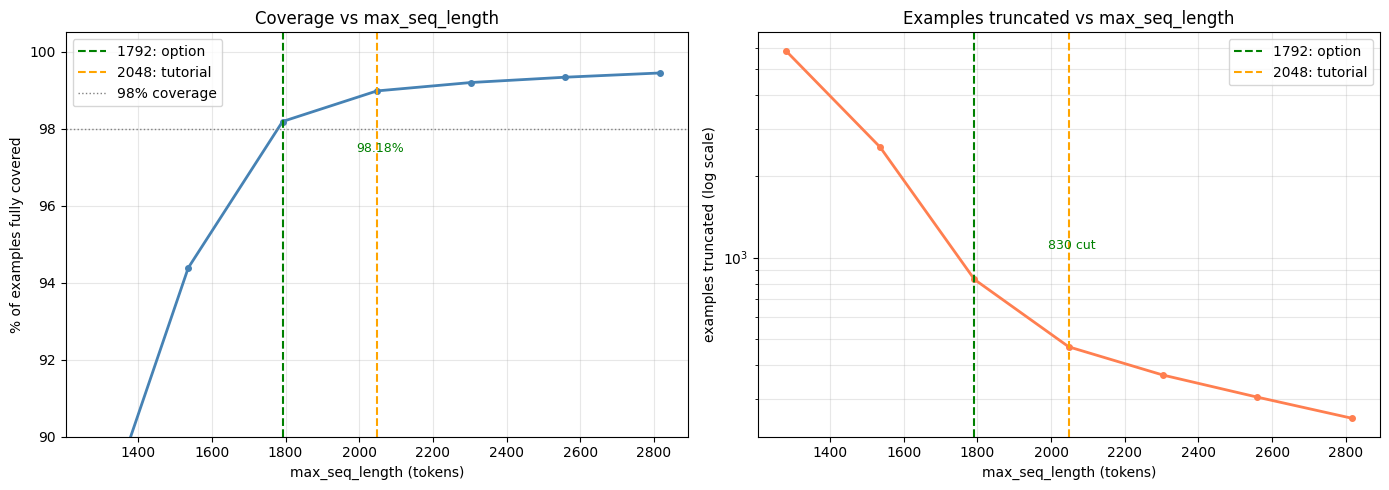

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

seq_lens_plot = (
    list(range(1280, 3072, 256))
)

coverage = [100 * (all_toks <= s).mean() for s in seq_lens_plot]
cut      = [(all_toks > s).sum()         for s in seq_lens_plot]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Annotate/investigate candidate point on both plots
seq_length = 1792

# Coverage
axes[0].plot(seq_lens_plot, coverage, color="steelblue", linewidth=2, marker="o", markersize=4)
axes[0].axvline(seq_length, color="green",  linestyle="--", linewidth=1.5, label=f"{seq_length}: option")
axes[0].axvline(2048, color="orange", linestyle="--", linewidth=1.5, label="2048: tutorial")
axes[0].axhline(98,   color="gray",   linestyle=":",  linewidth=1,   label="98% coverage")
axes[0].set_xlabel("max_seq_length (tokens)")
axes[0].set_ylabel("% of examples fully covered")
axes[0].set_title("Coverage vs max_seq_length")
axes[0].legend()
axes[0].set_ylim(90, 100.5)
axes[0].grid(True, alpha=0.3)

# examples cut (use log scale to see better)
axes[1].plot(seq_lens_plot, cut, color="coral", linewidth=2, marker="o", markersize=4)
axes[1].axvline(seq_length, color="green",  linestyle="--", linewidth=1.5, label=f"{seq_length}: option")
axes[1].axvline(2048, color="orange", linestyle="--", linewidth=1.5, label="2048: tutorial")
axes[1].set_xlabel("max_seq_length (tokens)")
axes[1].set_ylabel("examples truncated (log scale)")
axes[1].set_title("Examples truncated vs max_seq_length")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].grid(True, alpha=0.3, which="both")

chosen_idx = seq_lens_plot.index(seq_length)
axes[0].annotate(f"{coverage[chosen_idx]:.2f}%",
                 xy=(seq_length, coverage[chosen_idx]),
                 xytext=(seq_length + 200, coverage[chosen_idx] - 0.8),
                 fontsize=9, color="green")
axes[1].annotate(f"{cut[chosen_idx]:,} cut",
                 xy=(seq_length, cut[chosen_idx]),
                 xytext=(seq_length + 200, cut[chosen_idx] * 1.3),
                 fontsize=9, color="green")

plt.tight_layout()
plt.show()

### Observation: 2048 seems to be the last point before it flattens out

At 1792 tokens, more than 98% of the dataset is covered.

However, increasing to 2048 like in the starter notebook seems to gain nearly a full percent of data coverage. After that, there are diminishing returns (very small increases in coverage for large increases in tokens). This seems to be the safer option, without losing more complicated (longer) samples.

Capping at a reasonable token limit should increase resource efficiency and also hopefully encourage the model to produce simpler SVGs, while still allowing for most of the complex samples to survive.

### Decision: token limit = 2048

## 15 Build the filtered training dataset

Apply all filters in one final pipeline and save the result.

**Pipeline order:**
1. Start from `train_clean` (already rounded, de-duplicated,  attribute-cleaned, outliers removed)
2. Remove nulls and empty strings
3. Check SVG starts with `<svg`
4. Remove disallowed elements
5. Valid XML check
6. Filter by token limit


In [ ]:
TOKEN_LIMIT = 2048

# Start from the balanced, cleaned dataset
print(f"Starting with {len(train_clean):,} training examples (post-cleaning).")
filtered = train_clean.copy()

# Step 1: remove nulls and empty strings
filtered = filtered[
    filtered["prompt"].notna() & (filtered["prompt"].str.strip() != "") &
    filtered["svg_clean"].notna() & (filtered["svg_clean"].str.strip() != "")
]
print(f"After null/empty filter  : {len(filtered):,}")

# Step 2: SVG must start with <svg
filtered = filtered[filtered["svg_clean"].str.lstrip().str.startswith("<svg")]
print(f"After <svg check         : {len(filtered):,}")

# Step 3: no disallowed elements
# scripts, event handlers, animation, foreignObject, external references
DISALLOWED_TAGS = [
    "script",
    "animate",
    "animateTransform",
    "animateMotion",
    "foreignObject",
    "set",
]
for tag in DISALLOWED_TAGS:
    filtered = filtered[~filtered["svg_clean"].str.contains(f"<{tag}", case=False, na=False)]
print(f"After disallowed tag filter: {len(filtered):,}")

# Step 4: valid XML
def is_valid_xml(s):
    try:
        ET.fromstring(s if 'xmlns=' in s else s.replace('<svg','<svg xmlns="http://www.w3.org/2000/svg"',1))
        return True
    except ET.ParseError:
        return False

filtered = filtered[filtered["svg_clean"].apply(is_valid_xml)]
print(f"After XML validity filter : {len(filtered):,}")

# Step 5: token count filter
filtered["token_count"] = filtered.apply(
    lambda r: len(tokenizer.encode(format_training_example(FINAL_SYSTEM_PROMPT, r["prompt"], r["svg_clean"]))),
    axis=1
)
filtered = filtered[filtered["token_count"] <= TOKEN_LIMIT]
print(f"After token filter (≤{TOKEN_LIMIT}): {len(filtered):,}")
print(f"\nRetained {100*len(filtered)/len(train_df):.1f}% of original dataset")


Starting with 45,701 training examples (post-cleaning).
After null/empty filter  : 45,701
After <svg check         : 45,701
After disallowed tag filter: 45,701
After XML validity filter : 45,701
After token filter (≤2048): 45,239

Retained 98.5% of original dataset


In [ ]:
# Confirm token distribution on the final filtered set
final_toks = filtered["token_count"].values
print("Token counts in final filtered set:")
for pct in [50, 75, 90, 95, 99]:
    print(f"  p{pct}: {np.percentile(final_toks, pct):.0f} tokens")
pct_fit = 100 * (final_toks <= TOKEN_LIMIT).mean()
print(f"\n{pct_fit:.1f}% of examples fit within max_seq_length={TOKEN_LIMIT}")

Token counts in final filtered set:
  p50: 705 tokens
  p75: 996 tokens
  p90: 1311 tokens
  p95: 1492 tokens
  p99: 1744 tokens

100.0% of examples fit within max_seq_length=2048


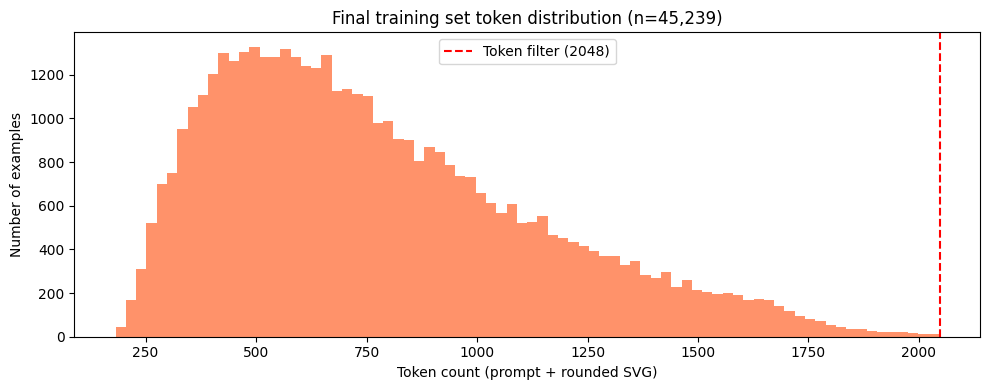

In [ ]:
# Visual confirmation: token distribution of the final training set
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(final_toks, bins=80, color="coral", edgecolor="none", alpha=0.85)
ax.axvline(TOKEN_LIMIT, color="red",  linestyle="--", linewidth=1.5,
           label=f"Token filter ({TOKEN_LIMIT})")
ax.set_xlabel("Token count (prompt + rounded SVG)")
ax.set_ylabel("Number of examples")
ax.set_title(f"Final training set token distribution (n={len(filtered):,})")
ax.legend()
plt.tight_layout()
plt.show()

## 16 Visual check of filtered examples

Before saving, render a few examples to confirm we
didn't visually break anything.

In [ ]:
from IPython.display import HTML

check = filtered.sample(n=10, random_state=42)

html_parts = []
for idx, row in check.iterrows():
    original_svg = train_df.loc[idx, "svg"]
    processed_svg = row["svg_clean"]
    tok_orig = len(tokenizer.encode(original_svg))
    tok_proc = len(tokenizer.encode(processed_svg))

    html_parts.append(f"""
    <div style='margin:12px 0; padding-bottom:12px; border-bottom:1px solid #eee;'>
        <p style='font-size:11px; color:#555; margin:4px 0;'>{row['prompt'][:100]}</p>
        <div style='display:flex; gap:32px; align-items:center;'>
            <div style='text-align:center'>
                <div style='font-size:11px;color:#888'>ORIGINAL ({tok_orig} tok)</div>
                {original_svg}
            </div>
            <div style='font-size:20px;color:#aaa'>→</div>
            <div style='text-align:center'>
                <div style='font-size:11px;color:#888'>PROCESSED ({tok_proc} tok, saved {tok_orig-tok_proc})</div>
                {processed_svg}
            </div>
        </div>
    </div>
    """)

display(HTML("".join(html_parts)))

## 17 Save the filtered dataset to HuggingFace

Save `train_filtered.csv` back to the HuggingFace repo.
Notebook 2 loads from this file for training.

Note: uploading requires write access. Set your HuggingFace token in Colab secrets (key icon in left sidebar) as `HF_TOKEN`.

In [ ]:
assert "svg_clean" in filtered.columns, \
    "Column chain broken! svg_clean missing from filtered"

filtered_clean = filtered[["id", "prompt"]].copy()
filtered_clean["svg"] = filtered["svg_clean"]
filtered_clean = filtered_clean.reset_index(drop=True)

LOCAL_FILTERED_PATH = "train_filtered.csv"
filtered_clean.to_csv(LOCAL_FILTERED_PATH, index=False)
print(f"Saved {len(filtered_clean):,} examples to {LOCAL_FILTERED_PATH}")
print(f"Columns: {list(filtered_clean.columns)}")
print(f"\nSample SVG (first 200 chars):")
print(filtered_clean.loc[0, 'svg'][:200])


Saved 45,239 examples to train_filtered.csv
Columns: ['id', 'prompt', 'svg']

Sample SVG (first 200 chars):
<svg width="32" height="16" viewBox="0 0 32 16">
  <path d="M0 8 L24 8 L32 8 L28 4 Z" />
</svg>


In [ ]:
# Upload to HuggingFace
# Requires HF_TOKEN with write access set in Colab secrets (key icon, left sidebar)
from huggingface_hub import HfApi
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

api = HfApi(token=os.environ["HF_TOKEN"])
api.upload_file(
    path_or_fileobj=LOCAL_FILTERED_PATH,
    path_in_repo="train_filtered.csv",
    repo_id=HF_DATASET_REPO,
    repo_type="dataset",
    commit_message=(
        f"Add filtered training set "
        f"({len(filtered_clean):,} rows, "
        f"token filter <={TOKEN_LIMIT}, "
        f"coords rounded to 1dp)"
    )
)
print(f"Uploaded train_filtered.csv to {HF_DATASET_REPO}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  train_filtered.csv          :  52%|#####2    | 23.1MB / 44.2MB            

Uploaded train_filtered.csv to aagoluoglu/text-to-svg


## 18 Summary and decisions for Notebook 2

This cell auto-generates a summary of the decisions made in this notebook.
The output below is what goes into Notebook 2's `CONFIG` block.

In [ ]:
print("=" * 60)
print("DECISIONS SUMMARY & Notebook 2 CONFIG")
print("=" * 60)
print(f"  Unique Training examples (raw, no duplicates)    : {len(train_df):,}")
print(f"  After cleaning & filtering                       : {len(filtered_clean):,}")
print()
print("  Cleaning pipeline applied to SVGs:")
print(f"    1. Coordinate rounding (to {DECIMALS} decimal/s)")
print(f"    X SKIPPED 2. Primitive normalization (path -> circle/ellipse/rect/line)")
print(f"    3. Remove duplicate prompts (keep simplest prompt+SVG pair for each)")
print(f"    4. Attribute cleaning (redundant attrs, short hex, no id/class)")
print(f"    5. Outlier removal (path count > {PATH_COUNT_LIMIT}, mismatch, degenerate, vague)")
print(f"    6. Filter for requirements and token count < {TOKEN_LIMIT}")
print()
print("  Token budget:")
print(f"    TOKEN_LIMIT (max_seq_length) : {TOKEN_LIMIT}")
print(f"    System prompt tokens         : ~{len(tokenizer.encode(FINAL_SYSTEM_PROMPT))}")
print()
print(f"  System prompt used: {FINAL_SYSTEM_PROMPT}")
print()
print("  Paste into Notebook 2 CONFIG:")
print(f"    HF_DATASET_REPO = 'aagoluoglu/text-to-svg'")
print(f"    TRAIN_FILE      = 'train_filtered.csv'")
print(f"    MODEL           = {MODEL_ID}")
print(f"    TOKEN_LIMIT     = {TOKEN_LIMIT}")
print(f"    SYSTEM_PROMPT   = {FINAL_SYSTEM_PROMPT}")


DECISIONS SUMMARY & Notebook 2 CONFIG
  Unique Training examples (raw, no duplicates)    : 45,931
  After cleaning & filtering                       : 45,239

  Cleaning pipeline applied to SVGs:
    1. Coordinate rounding (to 0 decimal/s)
    X SKIPPED 2. Primitive normalization (path -> circle/ellipse/rect/line)
    3. Remove duplicate prompts (keep simplest prompt+SVG pair for each)
    4. Attribute cleaning (redundant attrs, short hex, no id/class)
    5. Outlier removal (path count > 64, mismatch, degenerate, vague)
    6. Filter for requirements and token count < 2048

  Token budget:
    TOKEN_LIMIT (max_seq_length) : 2048
    System prompt tokens         : ~95

  System prompt used: You are an SVG code generator. Given a visual description, output only valid SVG code. Use semantic SVG elements: <circle> for circles, <rect> for rectangles, <ellipse> for ovals, <line> for straight lines, <polygon> for angular shapes, <path> for curves and complex outlines. Build complex objects b